This notebook tests 4 mamba architeture, puremamba, hybrid with resnet pretrain, with regulization, desnet pretrain. It then compares these model performance, genralizability. The a segementation head is added to these models for explainability. In addition Grad-Cam is used for explainability.

In [1]:
# Install dependencies
!pip install segmentation-models-pytorch
!pip install torchmetrics==0.11.0
!pip install opencv-python
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121
!pip install ninja
!pip install einops timm
!pip install thop -q
!pip install scikit-learn scikit-image pandas matplotlib seaborn tqdm
!pip install causal-conv1d>=1.4.0 --no-build-isolation
!pip install mamba-ssm --no-build-isolation
!git clone https://github.com/hustvl/Vim.git

print("Installation complete! Please restart runtime now.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 512.4/512.4 kB 10.3 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 68.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 88.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 85.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 61.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 111.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 777.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5

In [2]:
# Imports
import sys
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.datasets import ImageFolder
from torchvision import transforms
from einops import rearrange
from tqdm import tqdm
from google.colab import drive
import zipfile
import glob
import time
from functools import wraps
import json
from datetime import datetime
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report, roc_curve, auc, jaccard_score
from sklearn.model_selection import train_test_split
import cv2
import shutil
from PIL import Image
from scipy import ndimage
import random
import segmentation_models_pytorch as smp
from torchvision.models import resnet50, ResNet50_Weights
import timm
from IPython.display import display, Javascript
import threading
import torchmetrics
from scipy.ndimage import binary_dilation, label as ndimage_label

# Add Vim to path
sys.path.append('/content/Vim')
sys.path.append('/content/Vim/vim')

# Import mamba-ssm
try:
    from mamba_ssm import Mamba
    from mamba_ssm.models.config_mamba import MambaConfig
    print("mamba-ssm imported successfully")
except ImportError as e:
    print(f"Import error: {e}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


mamba-ssm imported successfully
Using device: cuda


In [17]:
from thop import profile

In [62]:
from sklearn.metrics import roc_auc_score
from collections import defaultdict
import matplotlib.patches as patches
from scipy.ndimage import zoom

In [3]:
# Loading Data
drive.mount('/content/drive')

zip_path = '/content/drive/MyDrive/MINI-DDSM-Complete-JPEG-8.zip'

# Check if the zip file exists
if os.path.exists(zip_path):
    print(f"✓ Found dataset at: {zip_path}")
    print(f"File size: {os.path.getsize(zip_path) / (1024**3):.2f} GB")

    # Create extraction directory
    extract_path = '/content/MINI-DDSM'
    os.makedirs(extract_path, exist_ok=True)

    # Extract the dataset
    print("Extracting dataset... (this may take 5-10 minutes)")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)
    print("✓ Extraction complete!")

    # Verify extraction
    print("\nDataset extracted to:", extract_path)

Mounted at /content/drive
✓ Found dataset at: /content/drive/MyDrive/MINI-DDSM-Complete-JPEG-8.zip
File size: 2.12 GB
Extracting dataset... (this may take 5-10 minutes)
✓ Extraction complete!

Dataset extracted to: /content/MINI-DDSM


In [4]:
# Data Processing
simple_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

heavy_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Helper Functions

In [5]:
#Helper Class
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_acc):
        if self.best_score is None:
            self.best_score = val_acc
        elif val_acc < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = val_acc
            self.counter = 0

In [6]:
#Helper Class
class ModelCheckpointer:
    def __init__(self, base_dir='/content/model_checkpoints'):
        self.base_dir = base_dir
        os.makedirs(base_dir, exist_ok=True)

    def save_checkpoint(self, model, model_name, epoch, optimizer=None,
                      metrics=None, is_best=False):
        checkpoint = {
            'model_name': model_name,
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict() if optimizer else None,
            'metrics': metrics or {},
        }

        # Define path outside the if block - THIS IS THE KEY FIX
        path = os.path.join(self.base_dir, f"{model_name}_epoch_{epoch}.pth")
        torch.save(checkpoint, path)

        if is_best:
            best_path = os.path.join(self.base_dir, f"{model_name}_best.pth")
            torch.save(checkpoint, best_path)
            print(f"Saved best {model_name} model")

        return path  # Now path is always defined

    def load_checkpoint(self, model_name, best=True):
        if best:
            path = os.path.join(self.base_dir, f"{model_name}_best.pth")
        else:
            files = [f for f in os.listdir(self.base_dir) if f.startswith(model_name)]
            if not files:
                return None
            latest = sorted(files)[-1]
            path = os.path.join(self.base_dir, latest)

        if os.path.exists(path):
            return torch.load(path)
        return None

checkpointer = ModelCheckpointer()

In [7]:
# Tor Prevent Crashing Helper Function
def keep_colab_active():
    def click_connect_button():
      js_code = """
        function ClickConnect(){
            console.log("Keeping Colab active...");
            document.querySelector("colab-connect-button").click()
        }
        setInterval(ClickConnect, 60000)
        """
      display(Javascript(js_code))

    # Also keep Python busy
    def keep_alive():
        while True:
            time.sleep(30)

    threading.Thread(target=keep_alive, daemon=True).start()
    click_connect_button()
    print("Keep-alive mechanism activated - Colab will stay connected")

In [8]:
# Time Comparison

def timer(func):

    @wraps(func)
    def wrapper(*args, **kwargs):
        start = time.time()
        result = func(*args, **kwargs)
        elapsed = time.time() - start
        print(f"⏱️ {func.__name__} took {elapsed:.2f} seconds ({elapsed/60:.2f} minutes)")
        return result, elapsed
    return wrapper

Model Definition

In [9]:
# Model 1: Pure Mamba Original
class PureMambaVision(nn.Module):
    def __init__(self, img_size=224, patch_size=16, num_classes=2):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_embed = nn.Conv2d(3, 384, kernel_size=patch_size, stride=patch_size)

        self.pos_embed = nn.Parameter(torch.randn(1, self.num_patches, 384) * 0.02)
        self.pos_drop = nn.Dropout(0.1)
        self.cls_token = nn.Parameter(torch.zeros(1, 1, 384))

        self.mamba_layers = nn.ModuleList([
            Mamba(d_model=384, d_state=16, d_conv=4, expand=2,
                 dt_rank='auto', bias=False, conv_bias=True) for _ in range(8)
        ])

        self.norms = nn.ModuleList([nn.LayerNorm(384) for _ in range(8)])
        self.final_norm = nn.LayerNorm(384)

        self.classifier = nn.Sequential(
            nn.Linear(384, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.patch_embed(x)
        B, D, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)

        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat([cls_tokens, x], dim=1)

        seq_len = x.shape[1]
        if seq_len != self.pos_embed.shape[1]:
            pos_embed = self.pos_embed.transpose(1, 2)
            pos_embed = F.interpolate(pos_embed, size=seq_len, mode='linear', align_corners=False)
            pos_embed = pos_embed.transpose(1, 2)
        else:
            pos_embed = self.pos_embed

        x = x + pos_embed
        x = self.pos_drop(x)

        for mamba, norm in zip(self.mamba_layers, self.norms):
            x_norm = norm(x)
            x = x + mamba(x_norm)

        cls_output = self.final_norm(x[:, 0, :])
        return self.classifier(cls_output)

In [10]:
# Model 2: Hybrid Mamba
class HybridMambaOriginal(nn.Module):
    def __init__(self, num_classes=2, num_seg_classes=2):
        super().__init__()

        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.classification_model = nn.Module()
        self.classification_model.encoder = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3,
        )

        self.classification_model.projection = nn.Conv2d(1024, 384, kernel_size=1)
        self.classification_model.mamba = Mamba(d_model=384, d_state=16, d_conv=4, expand=2,
                                               dt_rank='auto', bias=False, conv_bias=True)
        self.classification_model.seq_len = 14 * 14
        self.classification_model.pos_embed = nn.Parameter(torch.randn(1, 196, 384) * 0.02)
        self.classification_model.norm = nn.LayerNorm(384)
        self.classification_model.classifier = nn.Sequential(
            nn.Linear(384, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.classification_model.encoder(x)
        features = self.classification_model.projection(features)
        B, D, H, W = features.shape
        seq = features.flatten(2).transpose(1, 2) + self.classification_model.pos_embed
        seq = self.classification_model.mamba(seq)
        pooled = self.classification_model.norm(seq.mean(dim=1))
        return self.classification_model.classifier(pooled)

In [11]:
# Model 3: Hybrid Mamba Regularized
class HybridMambaRegularized(nn.Module):
    def __init__(self, num_classes=2, num_seg_classes=2, dropout_rate=0.5, use_attention=True):
        super().__init__()

        resnet = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        self.classification_model = nn.Module()
        self.classification_model.encoder = nn.Sequential(
            resnet.conv1, resnet.bn1, resnet.relu, resnet.maxpool,
            resnet.layer1, resnet.layer2, resnet.layer3,
        )

        # Freeze early layers
        for name, param in self.classification_model.encoder.named_parameters():
            if 'layer1' in name or 'layer2' in name or 'layer3' in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.classification_model.projection = nn.Conv2d(1024, 384, kernel_size=1)
        self.classification_model.projection_dropout = nn.Dropout2d(0.2)
        self.classification_model.mamba = Mamba(d_model=384, d_state=8, d_conv=4, expand=2,
                                               dt_rank='auto', bias=False, conv_bias=True)
        self.classification_model.seq_len = 14 * 14
        self.classification_model.pos_embed = nn.Parameter(torch.randn(1, 196, 384) * 0.02)
        self.classification_model.mamba_dropout = nn.Dropout(0.3)

        self.classification_model.use_attention = use_attention
        if use_attention:
            self.classification_model.attention = nn.Sequential(
                nn.Conv1d(384, 64, 1), nn.ReLU(),
                nn.Conv1d(64, 1, 1), nn.Softmax(dim=1)
            )

        self.classification_model.norm = nn.LayerNorm(384)
        self.classification_model.classifier = nn.Sequential(
            nn.Linear(384, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.classification_model.encoder(x)
        features = self.classification_model.projection(features)
        features = self.classification_model.projection_dropout(features)
        B, D, H, W = features.shape
        seq = features.flatten(2).transpose(1, 2) + self.classification_model.pos_embed
        seq = self.classification_model.mamba(seq)
        seq = self.classification_model.mamba_dropout(seq)

        if self.classification_model.use_attention:
            attn_input = seq.transpose(1, 2)
            attn_weights = self.classification_model.attention(attn_input)
            pooled = (attn_weights * attn_input).sum(dim=2)
        else:
            pooled = seq.mean(dim=1)

        pooled = self.classification_model.norm(pooled)
        return self.classification_model.classifier(pooled)

In [12]:
# Model 4: DenseNetMamba
class DenseNetMamba(nn.Module):
    def __init__(self, num_classes=2, num_seg_classes=2, dropout_rate=0.5, use_attention=True):
        super().__init__()
        self.feature_size = 7  # DenseNet outputs 7x7 feature maps
        self.seq_len = self.feature_size * self.feature_size  # 49


        self.classification_model = nn.Module()
        self.classification_model.backbone = timm.create_model("densenet121", pretrained=True, features_only=True)

        for name, param in self.classification_model.backbone.named_parameters():
            if "denseblock2" in name or "denseblock3" in name or "denseblock4" in name:
                param.requires_grad = True
            else:
                param.requires_grad = False

        self.classification_model.proj_channels = 384
        self.classification_model.projection = nn.Conv2d(1024, 384, kernel_size=1)
        self.classification_model.projection_dropout = nn.Dropout2d(0.2)
        self.classification_model.mamba = Mamba(d_model=384, d_state=16, d_conv=4, expand=2,
                                               dt_rank='auto', bias=False, conv_bias=True)
        self.classification_model.mamba_dropout = nn.Dropout(0.3)
        self.classification_model.seq_len = 14 * 14
        self.classification_model.pos_embed = nn.Parameter(torch.randn(1, self.seq_len, 384) * 0.02)

        self.classification_model.use_attention = use_attention
        if use_attention:
            self.classification_model.attention = nn.Sequential(
                nn.Conv1d(384, 64, 1), nn.ReLU(),
                nn.Conv1d(64, 1, 1), nn.Softmax(dim=2)
            )

        self.classification_model.norm = nn.LayerNorm(384)
        self.classification_model.classifier = nn.Sequential(
            nn.Linear(384, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(256, 128),
            nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        features = self.classification_model.backbone(x)[-1]
        features = self.classification_model.projection(features)
        features = self.classification_model.projection_dropout(features)
        B, C, H, W = features.shape
        seq = features.flatten(2).transpose(1, 2) + self.classification_model.pos_embed
        seq = self.classification_model.mamba(seq)
        seq = self.classification_model.mamba_dropout(seq)

        if self.classification_model.use_attention:
            attn_input = seq.transpose(1, 2)
            attn_weights = self.classification_model.attention(attn_input)
            pooled = (attn_weights * attn_input).sum(dim=2)
        else:
            pooled = seq.mean(dim=1)

        pooled = self.classification_model.norm(pooled)
        return self.classification_model.classifier(pooled)


In [15]:
# Model configurations
models_config = [
      {
        'name': 'PureMamba',
        'class': PureMambaVision,
        'params': {'img_size': 224, 'patch_size': 16, 'num_classes': 2},
        'transform': 'simple'
    },

    {
        'name': 'HybridMamba_Original',
        'class': HybridMambaOriginal,
        'params': {'num_classes': 2},
        'transform': 'simple'
    },
    {
        'name': 'HybridMamba_Regularized',
        'class': HybridMambaRegularized,
        'params': {'num_classes': 2, 'dropout_rate': 0.5, 'use_attention': True},
        'transform': 'heavy'
    },
    {
        'name': 'DenseNetMamba',
        'class': DenseNetMamba,
        'params': {'num_classes': 2, 'dropout_rate': 0.5, 'use_attention': True},
        'transform': 'heavy'
    }
]

In [18]:
# Quick FLOPs check (add after models_config)
for config in models_config:
    model = config['class'](**config['params']).to('cuda')
    dummy = torch.randn(1, 3, 224, 224).to('cuda')
    flops, params = profile(model, inputs=(dummy,), verbose=False)
    print(f"{config['name']}: {params/1e6:.1f}M params, {flops/1e9:.2f}G FLOPs")

PureMamba: 0.4M params, 0.06G FLOPs


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


HybridMamba_Original: 9.0M params, 3.40G FLOPs
HybridMamba_Regularized: 9.1M params, 3.40G FLOPs


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

DenseNetMamba: 7.4M params, 2.85G FLOPs


Classification Training

In [19]:
# Training Function with Early Stopping
@timer
def train_model(model, model_name, train_loader, val_loader, epochs=30, device='cuda'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-2)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    early_stopping = EarlyStopping(patience=7)

    best_acc = 0.0
    train_loss_history, train_acc_history = [], []
    val_loss_history, val_acc_history = [], []

    print(f"\n{'='*50}")
    print(f"Training {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, correct, total = 0.0, 0, 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for images, labels in train_bar:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            train_bar.set_postfix({'loss': f'{train_loss/(train_bar.n+1):.4f}',
                                  'acc': f'{100.*correct/total:.2f}%'})

        train_acc = 100. * correct / total

        # Validation
        model.eval()
        val_correct, val_total, val_loss = 0, 0, 0.0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += labels.size(0)
                val_correct += predicted.eq(labels).sum().item()

                val_bar.set_postfix({'acc': f'{100.*val_correct/val_total:.2f}%'})

        val_acc = 100. * val_correct / val_total

        scheduler.step(val_acc)

        train_loss_history.append(train_loss / len(train_loader))
        train_acc_history.append(train_acc)
        val_loss_history.append(val_loss / len(val_loader))
        val_acc_history.append(val_acc)

        print(f'\nEpoch {epoch+1} - Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')

        is_best = val_acc > best_acc
        if is_best:
            best_acc = val_acc

        metrics = {
            'train_acc': train_acc, 'val_acc': val_acc,
            'train_loss': train_loss / len(train_loader),
            'val_loss': val_loss / len(val_loader)
        }
        checkpointer.save_checkpoint(model, model_name, epoch, optimizer, metrics, is_best)

        if is_best:
            print(f'✅ New best model saved! ({best_acc:.2f}%)')

        early_stopping(val_acc)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    history = {
        'train_acc': train_acc_history, 'val_acc': val_acc_history,
        'train_loss': train_loss_history, 'val_loss': val_loss_history,
        'best_acc': best_acc
    }

    with open(f'/content/model_checkpoints/{model_name}_history.json', 'w') as f:
        json.dump(history, f)

    print(f"\n{model_name} complete! Best: {best_acc:.2f}%")
    return history

In [23]:
# Evaluation Function
def evaluate_model(model, model_name, val_loader, history, device='cuda'):
    print("\n" + "="*50)
    print(f"FINAL MODEL EVALUATION - {model_name}")
    print("="*50 + "\n")

    if not isinstance(history, dict):
        print(f"Warning: history is {type(history)}, expected dict. Creating empty history.")
        history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}


    required_keys = ['train_acc', 'val_acc', 'train_loss', 'val_loss']
    for key in required_keys:
        if key not in history:
            print(f"Warning: Missing '{key}' in history. Adding empty list.")
            history[key] = []
        elif not isinstance(history[key], list):
            print(f"Warning: '{key}' is {type(history[key])}, converting to list.")
            history[key] = list(history[key]) if history[key] else []

    model.eval()

    # Collect predictions
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Calculate metrics with safe handling
    accuracy = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
    conf_matrix = confusion_matrix(all_labels, all_preds)

    print("\n" + "="*50)
    print("CLASSIFICATION METRICS")
    print("="*50)
    print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
    print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
    print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
    print(f"F1-Score:  {f1:.4f} ({f1*100:.2f}%)")

    class_names = ['Benign', 'Malignant']
    print("\nCLASSIFICATION REPORT:")
    print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

    tn, fp, fn, tp = conf_matrix.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    print("\nPER-CLASS BREAKDOWN:")
    print(f"True Negatives: {tn}, False Positives: {fp}, False Negatives: {fn}, True Positives: {tp}")
    print(f"\nSensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"Specificity: {specificity:.4f} ({specificity*100:.2f}%)")

    # Plotting with safety checks
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'{model_name} - Training History and Performance', fontsize=16)

    # Check if we have training history data
    if len(history['train_acc']) > 0:
        epochs_range = range(1, len(history['train_acc']) + 1)

        axes[0, 0].plot(epochs_range, history['train_acc'], 'b-', label='Training Accuracy')
        axes[0, 0].plot(epochs_range, history['val_acc'], 'r-', label='Validation Accuracy')
        axes[0, 0].set_title('Training and Validation Accuracy')
        axes[0, 0].legend()
        axes[0, 0].grid(True)

        axes[0, 1].plot(epochs_range, history['train_loss'], 'b-', label='Training Loss')
        axes[0, 1].plot(epochs_range, history['val_loss'], 'r-', label='Validation Loss')
        axes[0, 1].set_title('Training and Validation Loss')
        axes[0, 1].legend()
        axes[0, 1].grid(True)
    else:
        axes[0, 0].text(0.5, 0.5, 'No training history available', ha='center', va='center')
        axes[0, 0].set_title('Training History (Not Available)')
        axes[0, 1].text(0.5, 0.5, 'No training history available', ha='center', va='center')
        axes[0, 1].set_title('Training History (Not Available)')

    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[1, 0],
                xticklabels=class_names, yticklabels=class_names)
    axes[1, 0].set_title(f'Confusion Matrix\nAccuracy: {accuracy:.2%}')

    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1', 'Sensitivity', 'Specificity']
    metrics_values = [accuracy, precision, recall, f1, sensitivity, specificity]
    bars = axes[1, 1].bar(metrics_names, metrics_values, color=['skyblue', 'lightgreen', 'coral', 'gold', 'lightpink', 'lightcyan'])
    axes[1, 1].set_ylim([0, 1])
    axes[1, 1].set_title('Performance Metrics')
    axes[1, 1].axhline(y=0.7, color='gray', linestyle='--')

    for bar, val in zip(bars, metrics_values):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', ha='center', fontsize=9)

    plt.tight_layout()
    plt.savefig(f'/content/explanations/{model_name}_evaluation.png', dpi=300, bbox_inches='tight')
    plt.show()

    # ROC Curve with safety check for binary classification
    if len(np.unique(all_labels)) == 2 and all_probs.shape[1] >= 2:
        fpr, tpr, _ = roc_curve(all_labels, all_probs[:, 1])
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], 'k--', label='Random')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title(f'{model_name} - ROC Curve')
        plt.legend()
        plt.grid(True)
        plt.savefig(f'/content/explanations/{model_name}_roc.png', dpi=300)
        plt.show()

        print(f"\nROC-AUC Score: {roc_auc:.4f}")
    else:
        print(f"\nROC-AUC Score: Not available (need binary classification with 2 classes)")
        roc_auc = 0.0

    return {
        'accuracy': accuracy, 'precision': precision, 'recall': recall,
        'f1': f1, 'sensitivity': sensitivity, 'specificity': specificity,
        'roc_auc': roc_auc, 'conf_matrix': conf_matrix.tolist()
    }

# Sample Prediction Visualization
def visualize_sample_predictions(model, model_name, val_loader, device='cuda'):
    print("\n" + "="*50)
    print(f"SAMPLE PREDICTIONS - {model_name}")
    print("="*50)

    def denormalize(tensor):
        tensor = tensor.clone().detach().cpu()
        mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
        for t, m, s in zip(tensor, mean, std):
            t.mul_(s).add_(m)
        return tensor

    model.eval()
    benign_samples, malignant_samples = [], []
    benign_labels, malignant_labels = [], []
    benign_preds, malignant_preds = [], []
    benign_probs, malignant_probs = [], []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            for i in range(len(labels)):
                if labels[i] == 0 and len(benign_samples) < 2:
                    benign_samples.append(images[i].cpu())
                    benign_labels.append(labels[i].cpu())
                    benign_preds.append(predicted[i].cpu())
                    benign_probs.append(probs[i].cpu().numpy())
                elif labels[i] == 1 and len(malignant_samples) < 3:
                    malignant_samples.append(images[i].cpu())
                    malignant_labels.append(labels[i].cpu())
                    malignant_preds.append(predicted[i].cpu())
                    malignant_probs.append(probs[i].cpu().numpy())

            if len(benign_samples) == 2 and len(malignant_samples) == 3:
                break

    all_samples = benign_samples + malignant_samples
    all_labels = benign_labels + malignant_labels
    all_preds = benign_preds + malignant_preds
    all_probs = benign_probs + malignant_probs

    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'{model_name} - Sample Predictions: Benign (0) vs Malignant (1)', fontsize=16)

    class_names = ['Benign', 'Malignant']
    colors = ['green', 'red']

    for i, ax in enumerate(axes):
        img = denormalize(all_samples[i])
        img = np.clip(img.numpy().transpose(1, 2, 0), 0, 1)

        ax.imshow(img)
        ax.axis('off')

        true_label = all_labels[i].item()
        pred_label = all_preds[i].item()
        confidence = all_probs[i][pred_label] * 100

        title_color = 'green' if pred_label == true_label else 'red'
        title = f'True: {class_names[true_label]}\nPred: {class_names[pred_label]}\nConf: {confidence:.1f}%'
        ax.set_title(title, color=title_color, fontsize=10)

    plt.tight_layout()
    plt.savefig(f'{model_name}_sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Sample predictions saved as '{model_name}_sample_predictions.png'")

In [24]:
def run_all_experiments(models_config, full_data):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    train_size = int(0.8 * len(full_data))
    val_size = len(full_data) - train_size
    train_data, val_data = random_split(full_data, [train_size, val_size])

    print(f"\nDataset: {len(train_data)} train, {len(val_data)} validation")

    all_results = {}

    for config in models_config:
        print(f"\n{'='*60}")
        print(f"Processing {config['name']}")
        print(f"{'='*60}")

        # Set transforms based on model type
        train_transform = heavy_transform if config['transform'] == 'heavy' else simple_transform
        train_data.dataset.transform = train_transform
        val_data.dataset.transform = val_transform

        train_loader = DataLoader(train_data, batch_size=32, shuffle=True, num_workers=2)
        val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=2)

        # Check for existing checkpoint
        checkpoint = checkpointer.load_checkpoint(config['name'], best=True)

        if checkpoint:
            print(f"✓ Found existing checkpoint")
            model = config['class'](**config['params']).to(device)
            model.load_state_dict(checkpoint['model_state_dict'])

            # Load history with validation
            history_path = f'/content/model_checkpoints/{config["name"]}_history.json'
            if os.path.exists(history_path):
                with open(history_path, 'r') as f:
                    history = json.load(f)

                    if isinstance(history, dict):

                        for key in ['train_acc', 'val_acc', 'train_loss', 'val_loss']:
                            if key not in history:
                                history[key] = []
                            elif not isinstance(history[key], list):
                                history[key] = [history[key]] if history[key] else []
                    else:
                        print(f"Warning: History file contains {type(history)}, resetting")
                        history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
            else:
                print(f"Warning: No history file found for {config['name']}")
                history = {'train_acc': [], 'val_acc': [], 'train_loss': [], 'val_loss': []}
        else:
            print(f"Training new model...")
            model = config['class'](**config['params']).to(device)
            history = train_model(model, config['name'], train_loader, val_loader, epochs=30, device=device)

        # Store results
        all_results[config['name']] = {
            'model': model,
            'history': history
        }

        # Evaluation
        metrics = evaluate_model(model, config['name'], val_loader, history, device)

        # Sample Predictions
        visualize_sample_predictions(model, config['name'], val_loader, device)

    # Save summary (only if we have results)
    if all_results:
        summary = {
            'models': list(all_results.keys()),
            'best_accuracies': {},
            'timestamp': str(datetime.now())
        }

        for name, results in all_results.items():
            if results['history'] and 'val_acc' in results['history'] and results['history']['val_acc']:
                summary['best_accuracies'][name] = max(results['history']['val_acc'])
            else:
                summary['best_accuracies'][name] = 0.0

        with open('/content/explanations/experiment_summary.json', 'w') as f:
            json.dump(summary, f, indent=2)

        print("\nResults saved in:")
        print("   - /content/model_checkpoints/ (model weights)")
        print("   - /content/explanations/ (evaluation plots)")
        print("\nBest Accuracies:")
        for name, acc in summary['best_accuracies'].items():
            print(f"   {name}: {acc:.2f}%")
    else:
        print("\nNo results to save.")

    return all_results

<IPython.core.display.Javascript object>

Keep-alive mechanism activated - Colab will stay connected
Using device: cuda

Dataset: 6772 train, 1693 validation

Processing PureMamba


/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


✓ Found existing checkpoint

FINAL MODEL EVALUATION - PureMamba



Evaluating: 100%|██████████| 53/53 [00:58<00:00,  1.10s/it]



CLASSIFICATION METRICS
Accuracy:  0.5092 (50.92%)
Precision: 0.5092 (50.92%)
Recall:    1.0000 (100.00%)
F1-Score:  0.6748 (67.48%)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       831
   Malignant       0.51      1.00      0.67       862

    accuracy                           0.51      1693
   macro avg       0.25      0.50      0.34      1693
weighted avg       0.26      0.51      0.34      1693


PER-CLASS BREAKDOWN:
True Negatives: 0, False Positives: 831, False Negatives: 0, True Positives: 862

Sensitivity: 1.0000 (100.00%)
Specificity: 0.0000 (0.00%)


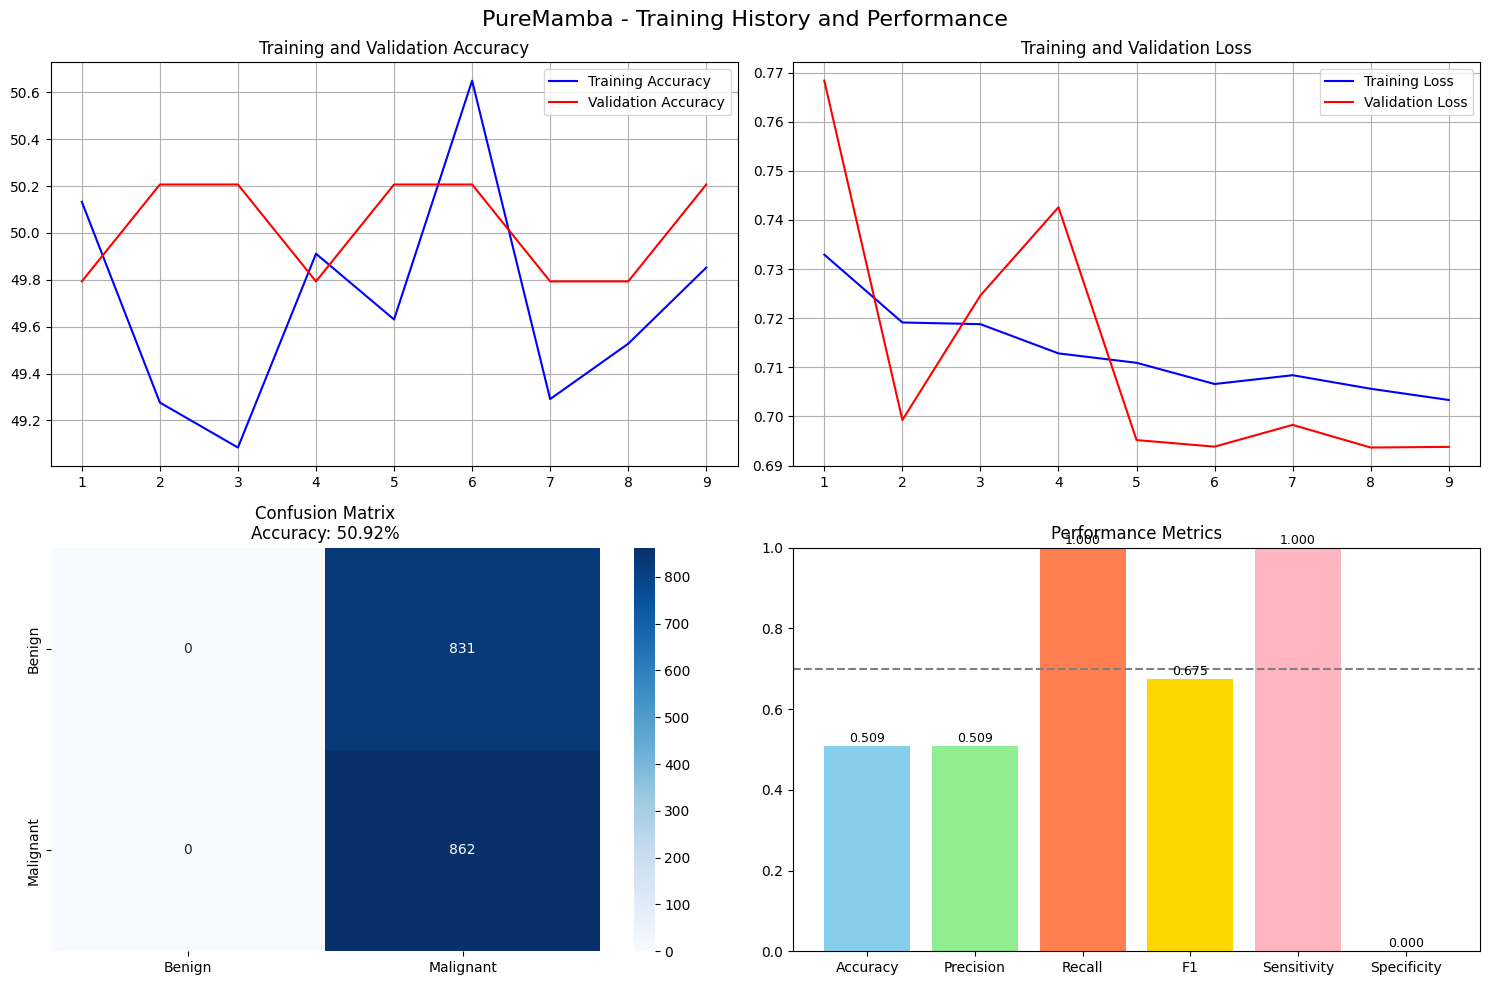

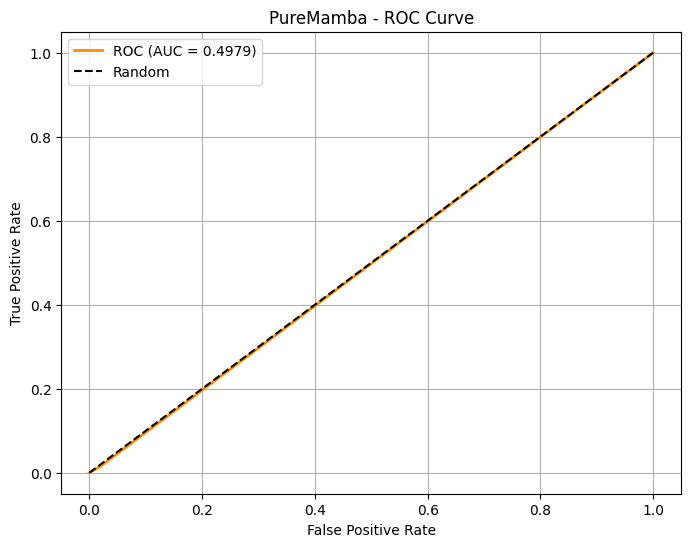


ROC-AUC Score: 0.4979

SAMPLE PREDICTIONS - PureMamba


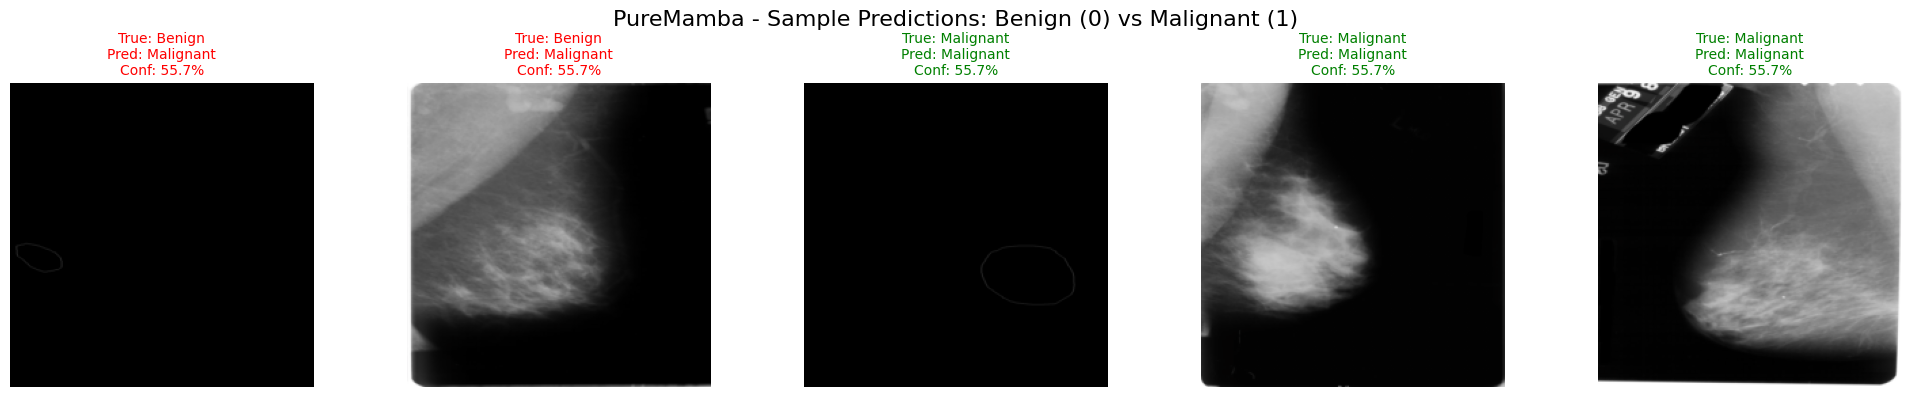

Sample predictions saved as 'PureMamba_sample_predictions.png'

Processing HybridMamba_Original


/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


✓ Found existing checkpoint

FINAL MODEL EVALUATION - HybridMamba_Original



Evaluating: 100%|██████████| 53/53 [00:59<00:00,  1.11s/it]



CLASSIFICATION METRICS
Accuracy:  0.9462 (94.62%)
Precision: 0.9541 (95.41%)
Recall:    0.9397 (93.97%)
F1-Score:  0.9468 (94.68%)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.94      0.95      0.95       831
   Malignant       0.95      0.94      0.95       862

    accuracy                           0.95      1693
   macro avg       0.95      0.95      0.95      1693
weighted avg       0.95      0.95      0.95      1693


PER-CLASS BREAKDOWN:
True Negatives: 792, False Positives: 39, False Negatives: 52, True Positives: 810

Sensitivity: 0.9397 (93.97%)
Specificity: 0.9531 (95.31%)


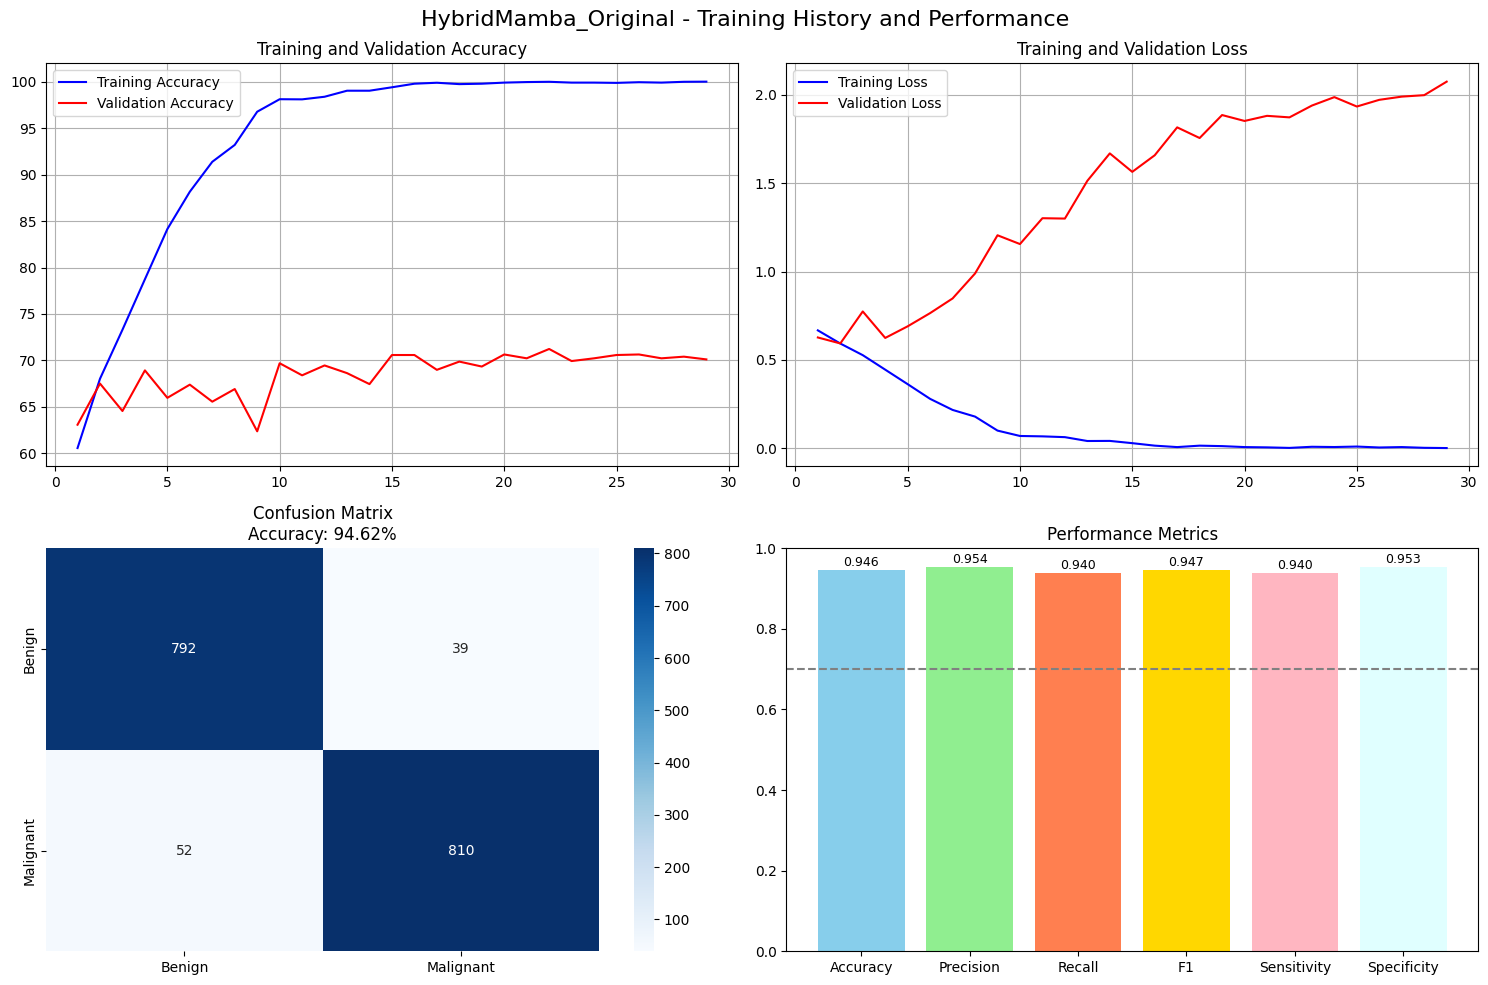

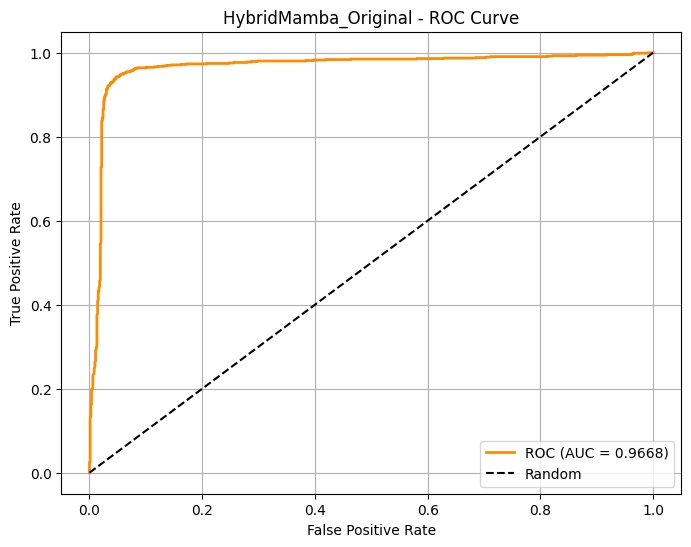


ROC-AUC Score: 0.9668

SAMPLE PREDICTIONS - HybridMamba_Original


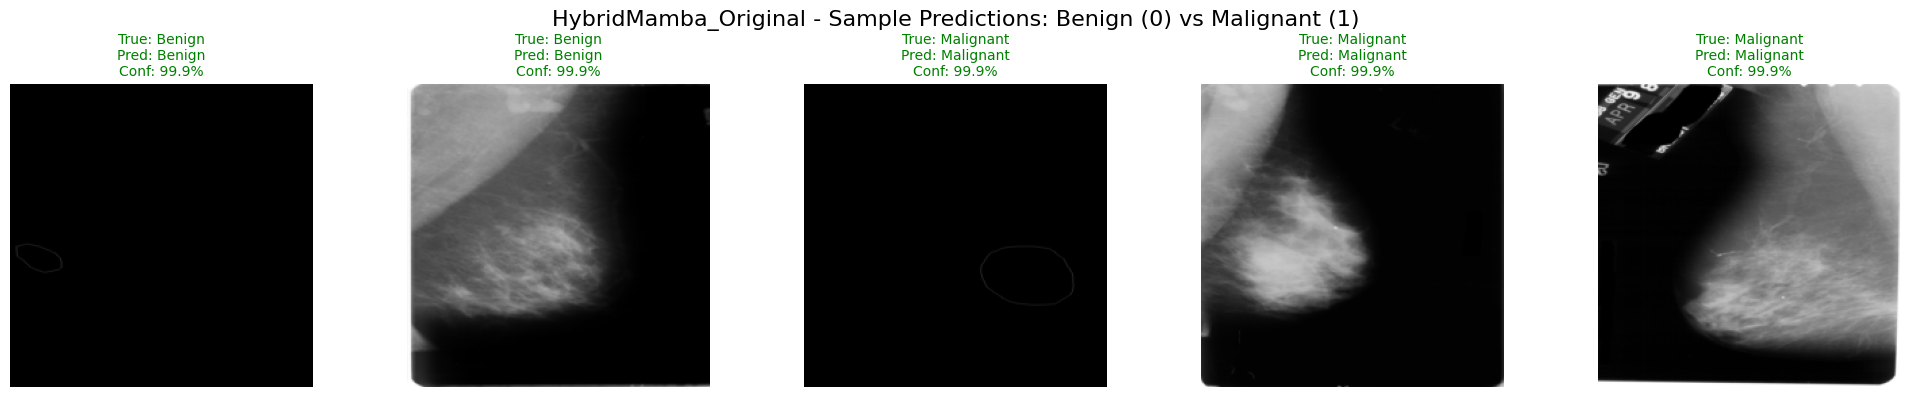

Sample predictions saved as 'HybridMamba_Original_sample_predictions.png'

Processing HybridMamba_Regularized


/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


✓ Found existing checkpoint

FINAL MODEL EVALUATION - HybridMamba_Regularized



Evaluating: 100%|██████████| 53/53 [00:59<00:00,  1.12s/it]



CLASSIFICATION METRICS
Accuracy:  0.7944 (79.44%)
Precision: 0.8492 (84.92%)
Recall:    0.7251 (72.51%)
F1-Score:  0.7822 (78.22%)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.75      0.87      0.81       831
   Malignant       0.85      0.73      0.78       862

    accuracy                           0.79      1693
   macro avg       0.80      0.80      0.79      1693
weighted avg       0.80      0.79      0.79      1693


PER-CLASS BREAKDOWN:
True Negatives: 720, False Positives: 111, False Negatives: 237, True Positives: 625

Sensitivity: 0.7251 (72.51%)
Specificity: 0.8664 (86.64%)


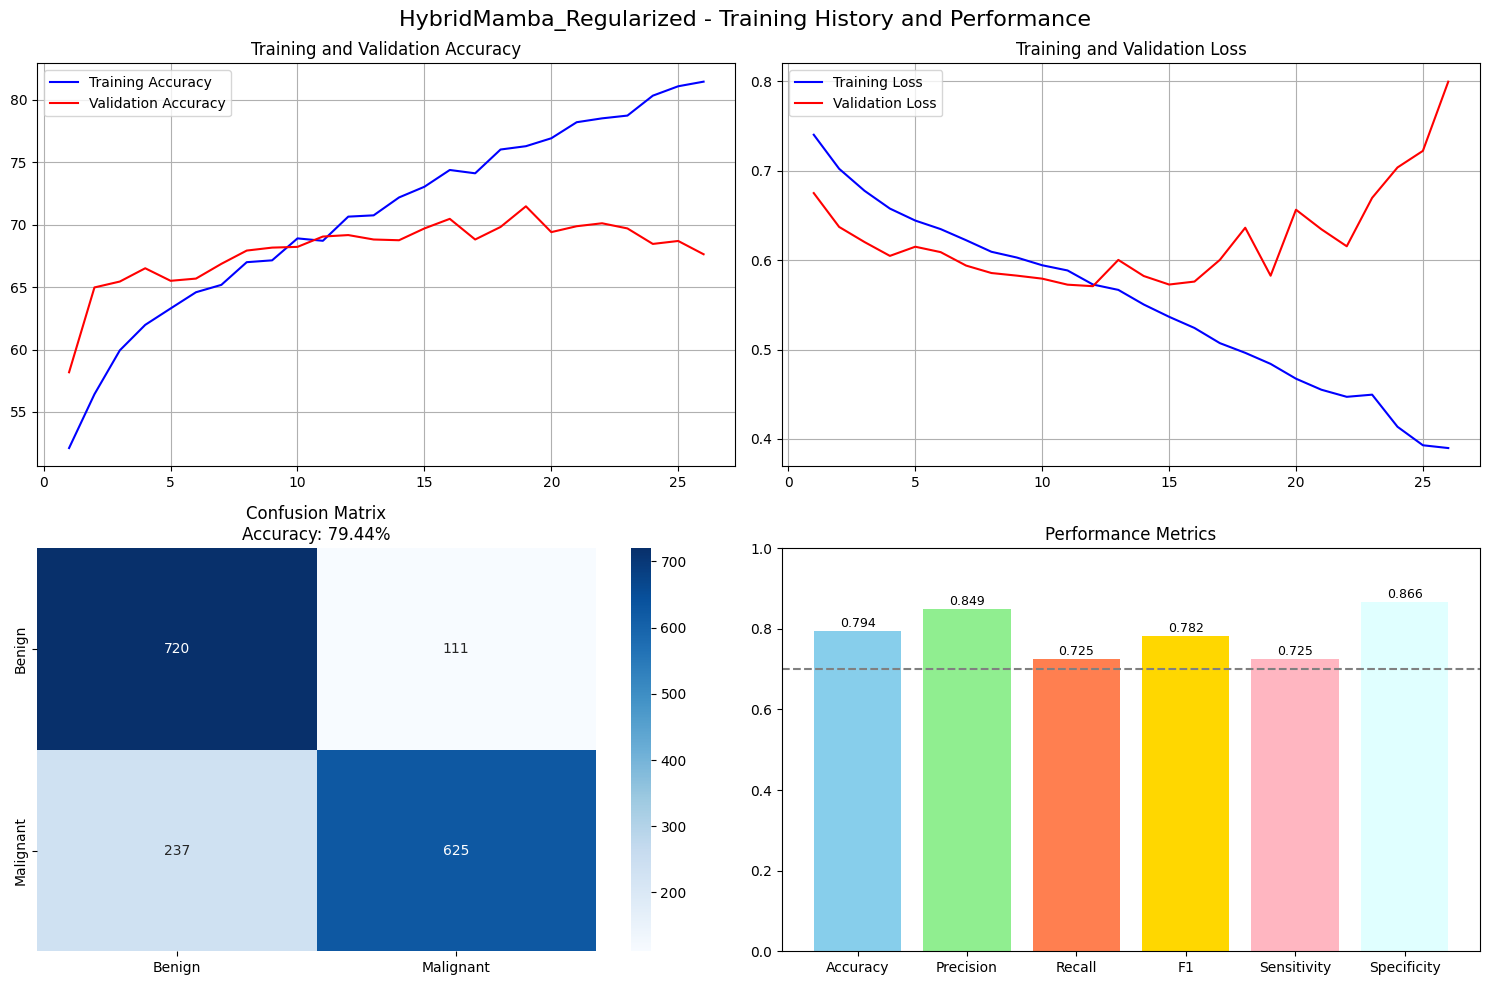

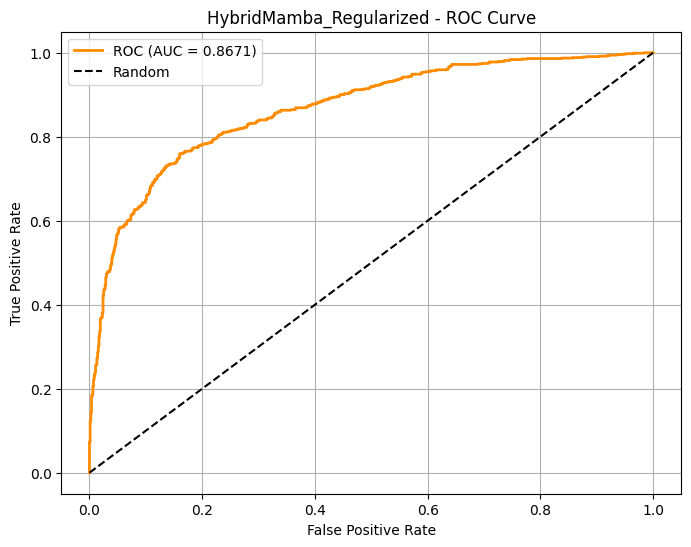


ROC-AUC Score: 0.8671

SAMPLE PREDICTIONS - HybridMamba_Regularized


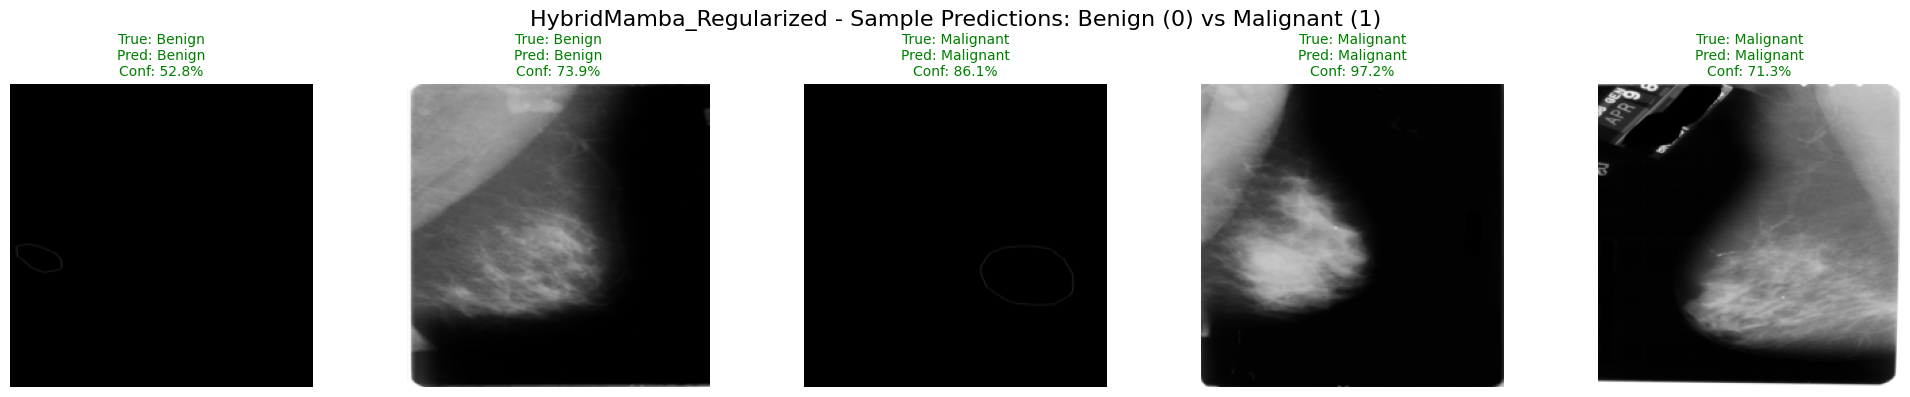

Sample predictions saved as 'HybridMamba_Regularized_sample_predictions.png'

Processing DenseNetMamba


/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


✓ Found existing checkpoint

FINAL MODEL EVALUATION - DenseNetMamba



Evaluating: 100%|██████████| 53/53 [00:59<00:00,  1.13s/it]



CLASSIFICATION METRICS
Accuracy:  0.8754 (87.54%)
Precision: 0.9054 (90.54%)
Recall:    0.8434 (84.34%)
F1-Score:  0.8733 (87.33%)

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

      Benign       0.85      0.91      0.88       831
   Malignant       0.91      0.84      0.87       862

    accuracy                           0.88      1693
   macro avg       0.88      0.88      0.88      1693
weighted avg       0.88      0.88      0.88      1693


PER-CLASS BREAKDOWN:
True Negatives: 755, False Positives: 76, False Negatives: 135, True Positives: 727

Sensitivity: 0.8434 (84.34%)
Specificity: 0.9085 (90.85%)


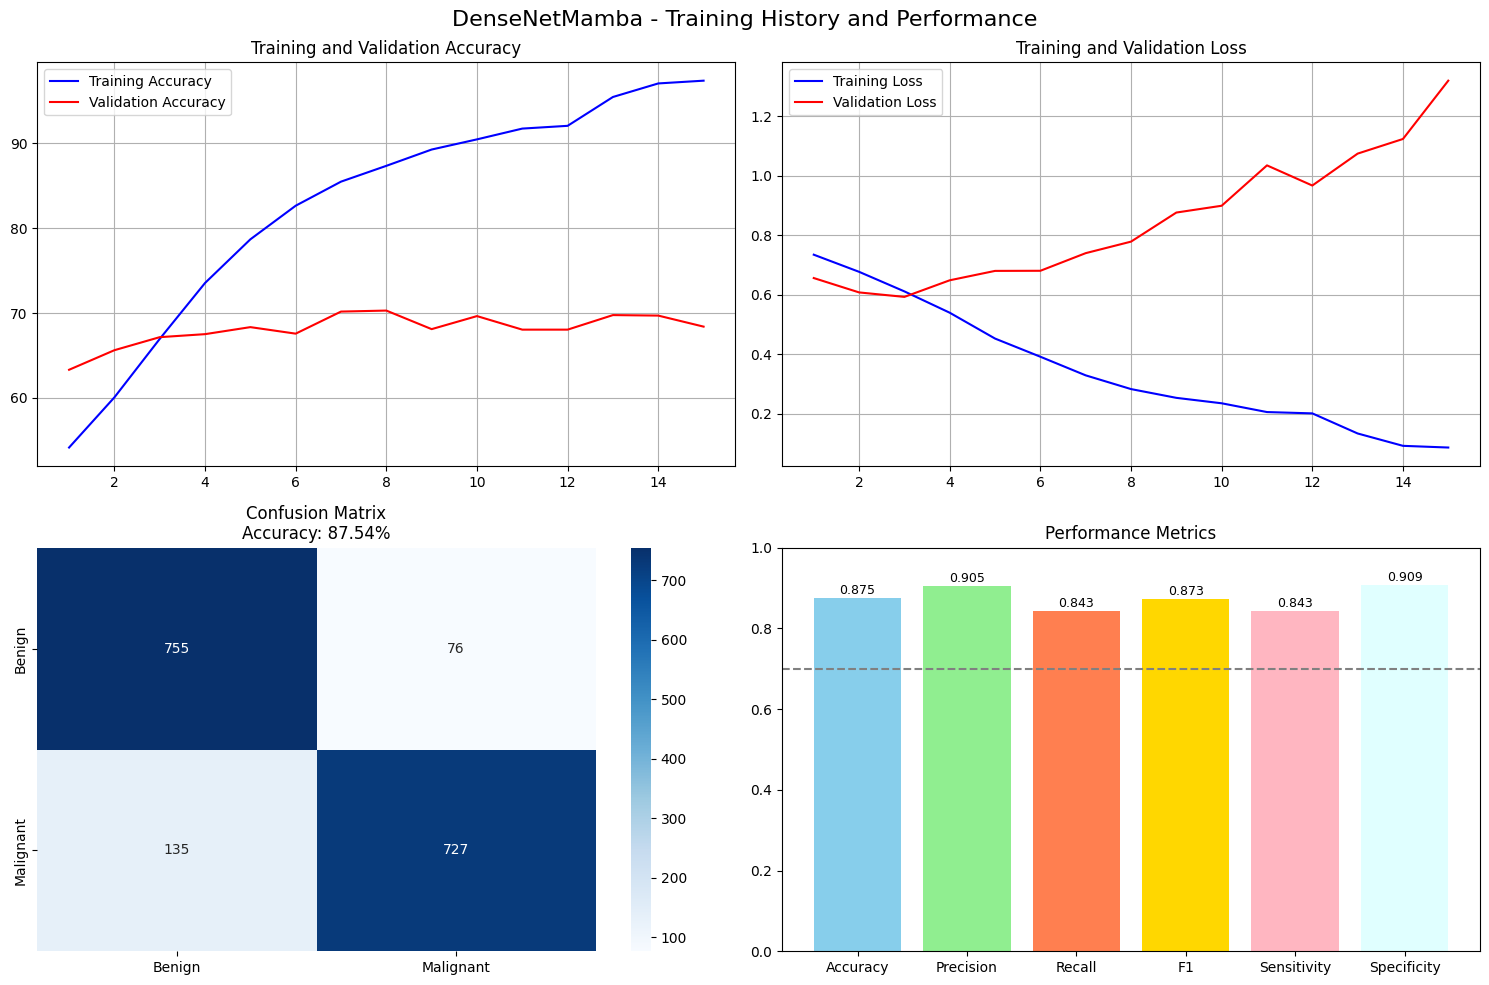

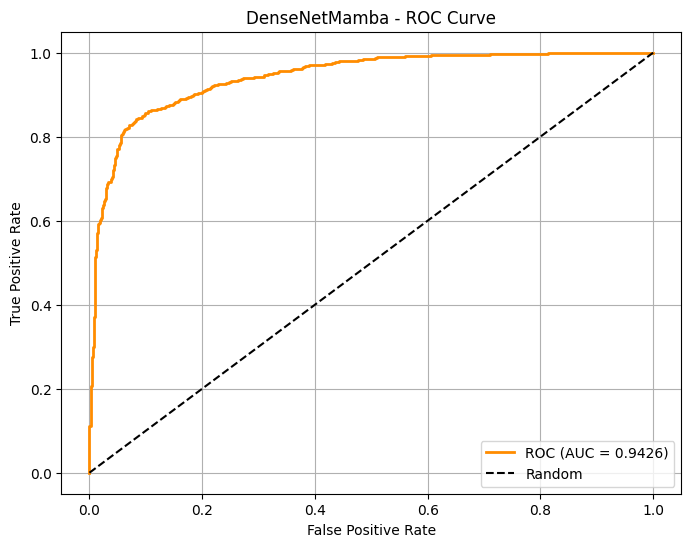


ROC-AUC Score: 0.9426

SAMPLE PREDICTIONS - DenseNetMamba


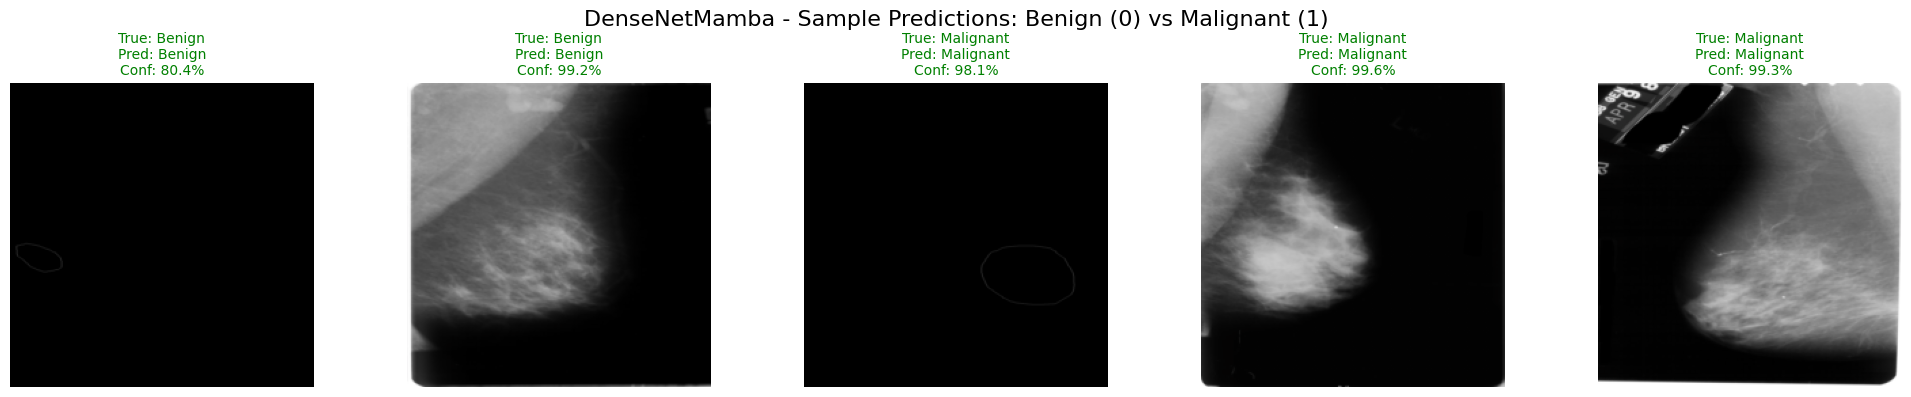

Sample predictions saved as 'DenseNetMamba_sample_predictions.png'

Results saved in:
   - /content/model_checkpoints/ (model weights)
   - /content/explanations/ (evaluation plots)

Best Accuracies:
   PureMamba: 50.21%
   HybridMamba_Original: 71.23%
   HybridMamba_Regularized: 71.47%
   DenseNetMamba: 70.29%


In [26]:
# Run Everything
if __name__ == "__main__":
    # Create directories
    os.makedirs('/content/model_checkpoints', exist_ok=True)
    os.makedirs('/content/explanations', exist_ok=True)

    # Activate keep-alive
    keep_colab_active()

    # Load dataset
    base_dir = '/content/MINI-DDSM'
    full_data = ImageFolder(root=base_dir)

    # Run experiments
    results = run_all_experiments(models_config, full_data)

In [27]:
# Saving all checkpoints to Google Drive
drive_path = '/content/drive/MyDrive/model_checkpoints/'
os.makedirs(drive_path, exist_ok=True)

model_names = ['PureMamba', 'HybridMamba_Original', 'HybridMamba_Regularized', 'DenseNetMamba']

for model_name in model_names:
    source = f'/content/model_checkpoints/{model_name}_best.pth'
    dest = f'{drive_path}/{model_name}_best.pth'

    if os.path.exists(source):
        shutil.copy(source, dest)
        print(f"Saved {model_name} to Google Drive")
    else:
        print(f"{model_name} checkpoint not found")

Saved PureMamba to Google Drive
Saved HybridMamba_Original to Google Drive
Saved HybridMamba_Regularized to Google Drive
Saved DenseNetMamba to Google Drive


In [28]:
# Loading Checkpoints
os.makedirs('/content/model_checkpoints', exist_ok=True)

# Path to your checkpoints in Drive
drive_checkpoint_path = '/content/drive/MyDrive/model_checkpoints/'

# List all models you want to use
model_names = ['HybridMamba_Original', 'HybridMamba_Regularized', 'DenseNetMamba', 'PureMamba']

# Copy checkpoints from Drive to local
for model_name in model_names:
    source = f'{drive_checkpoint_path}/{model_name}_best.pth'
    dest = f'/content/model_checkpoints/{model_name}_best.pth'

    if os.path.exists(source):
        shutil.copy(source, dest)
        print(f"✅ Copied {model_name} checkpoint")

        # Check file size to verify
        size = os.path.getsize(dest) / (1024 * 1024)
        print(f"   Size: {size:.2f} MB")
    else:
        print(f"{model_name} checkpoint not found at {source}")

print("\nAll checkpoints imported!")

✅ Copied HybridMamba_Original checkpoint
   Size: 115.09 MB
✅ Copied HybridMamba_Regularized checkpoint
   Size: 50.83 MB
✅ Copied DenseNetMamba checkpoint
   Size: 90.15 MB
✅ Copied PureMamba checkpoint
   Size: 93.25 MB

All checkpoints imported!


Generalization

In [63]:
# BREAST MNIST DATASET LOADER
class BreastMNISTDataset(Dataset):

    def __init__(self, data_path='/content/drive/MyDrive/breastmnist_64.npz', transform=None):
        self.transform = transform

        # Load dataset
        data = np.load(data_path)

        print(f"Loading Breast MNIST from: {data_path}")
        print(f"Available keys: {list(data.keys())}")

        # Try different possible key names
        if 'image' in data.keys():
            self.images = data['image']
        elif 'images' in data.keys():
            self.images = data['images']
        elif 'x' in data.keys():
            self.images = data['x']
        elif 'data' in data.keys():
            self.images = data['data']
        else:
            # If no standard key, use the first array
            first_key = list(data.keys())[0]
            self.images = data[first_key]
            print(f"Using '{first_key}' as image data")

        if 'label' in data.keys():
            self.labels = data['label']
        elif 'labels' in data.keys():
            self.labels = data['labels']
        elif 'y' in data.keys():
            self.labels = data['y']
        else:
            # Try to find labels in second key
            if len(data.keys()) > 1:
                second_key = list(data.keys())[1]
                self.labels = data[second_key]
                print(f"Using '{second_key}' as label data")
            else:
                raise KeyError("No label data found in NPZ file")

        # Handle shape
        print(f"Original images shape: {self.images.shape}")
        print(f"Original labels shape: {self.labels.shape}")

        # Reshape if needed
        if len(self.images.shape) == 3:
            # Assuming (n_samples, height, width)
            self.images = self.images.reshape(-1, 1, self.images.shape[1], self.images.shape[2])
        elif len(self.images.shape) == 4:
            # Already has channel dimension
            if self.images.shape[1] > 1 and self.images.shape[1] <= 4:
                pass  # Keep as is
            else:
                # Maybe channels last
                self.images = self.images.transpose(0, 3, 1, 2)

        # Normalize to [0, 1] if not already
        if self.images.max() > 1.0:
            self.images = self.images.astype(np.float32) / 255.0

        # Ensure labels are 1D
        self.labels = self.labels.flatten()

        # Convert to binary if needed
        unique_labels = np.unique(self.labels)
        if len(unique_labels) > 2:
            print(f"Warning: Found {len(unique_labels)} unique labels. Using first two as benign/malignant")
            # Map first two unique values to 0 and 1
            label_map = {unique_labels[0]: 0, unique_labels[1]: 1}
            self.labels = np.array([label_map[l] for l in self.labels])

        print(f"\nLoaded Breast MNIST: {len(self.labels)} samples")
        print(f"   Images shape: {self.images.shape}")
        print(f"   Benign (0): {sum(self.labels == 0)}")
        print(f"   Malignant (1): {sum(self.labels == 1)}")

        # Show a few samples
        print(f"\n   Sample labels: {self.labels[:10]}")

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]

        # Ensure 3 channels (RGB) for pretrained models
        if img.shape[0] == 1:
            img = np.repeat(img, 3, axis=0)
        elif img.shape[0] == 3:
            pass  # Already RGB
        elif img.shape[0] > 3:
            img = img[:3]  # Take first 3 channels

        img = torch.FloatTensor(img)

        # Resizing to 224x224
        if self.transform:
            img = self.transform(img)
        else:
            # Default resize
            img = F.interpolate(img.unsqueeze(0), size=(224, 224), mode='bilinear').squeeze(0)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label, f"sample_{idx}", "BREAST"

    def show_sample(self, idx):

        img = self.images[idx]
        if img.shape[0] > 1:
            img = img[0]  # Take first channel
        plt.figure(figsize=(4, 4))
        plt.imshow(img, cmap='gray')
        plt.title(f"Label: {'Malignant' if self.labels[idx] == 1 else 'Benign'}")
        plt.axis('off')
        plt.show()

In [64]:
# TEST MODELS ON BREAST MNIST

def test_models_on_breast_mnist(models_config, checkpointer, device):

    print("\n" + "="*70)
    print("TESTING MODELS ON BREAST MNIST")
    print("="*70)

    # Simple transform for Breast MNIST
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # Create dataset
    try:
        dataset = BreastMNISTDataset(transform=transform)
    except Exception as e:
        print(f"Failed to load dataset: {e}")
        return {}

    # Load Data
    test_loader = DataLoader(dataset, batch_size=32, shuffle=False)

    print(f"\nTest set: {len(dataset)} samples")

    # Test each model
    results = {}

    for config in models_config:
        print(f"\nTesting {config['name']} on Breast MNIST...")

        # Load checkpoint
        checkpoint = checkpointer.load_checkpoint(config['name'], best=True)
        if not checkpoint:
            checkpoint = checkpointer.load_checkpoint(config['name'].replace('_', ''), best=True)

        if not checkpoint:
            print(f"No checkpoint found for {config['name']}")
            continue

        # Create model
        model = config['class'](**config['params']).to(device)

        # Load weights
        try:
            if 'model_state_dict' in checkpoint:
                model.load_state_dict(checkpoint['model_state_dict'])
            else:
                model.load_state_dict(checkpoint)
            print(f"Model loaded")
        except Exception as e:
            print(f"Error loading weights: {e}")
            continue

        model.eval()

        # Test
        all_preds = []
        all_labels = []
        all_probs = []

        with torch.no_grad():
            for images, labels, _, _ in tqdm(test_loader, desc=f"Testing {config['name']}"):
                images = images.to(device)
                outputs = model(images)
                probs = torch.softmax(outputs, dim=1)
                _, predicted = outputs.max(1)

                all_preds.extend(predicted.cpu().numpy())
                all_labels.extend(labels.numpy())
                all_probs.extend(probs.cpu().numpy())

        # Calculate metrics
        accuracy = accuracy_score(all_labels, all_preds)
        precision = precision_score(all_labels, all_preds, average='binary', zero_division=0)
        recall = recall_score(all_labels, all_preds, average='binary', zero_division=0)
        f1 = f1_score(all_labels, all_preds, average='binary', zero_division=0)
        conf_matrix = confusion_matrix(all_labels, all_preds)

        try:
            probs_positive = [p[1] for p in all_probs]
            auc = roc_auc_score(all_labels, probs_positive)
        except:
            auc = 0.0

        results[config['name']] = {
            'accuracy': accuracy,
            'precision': precision,
            'recall': recall,
            'f1': f1,
            'auc': auc,
            'conf_matrix': conf_matrix
        }

        print(f"\n    Results on Breast MNIST:")
        print(f"      Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
        print(f"      Precision: {precision:.4f}")
        print(f"      Recall:    {recall:.4f}")
        print(f"      F1-Score:  {f1:.4f}")
        print(f"      AUC:       {auc:.4f}")
        print(f"\n   Confusion Matrix:")
        print(f"      [[{conf_matrix[0,0]:3d} {conf_matrix[0,1]:3d}]")
        print(f"       [{conf_matrix[1,0]:3d} {conf_matrix[1,1]:3d}]]")

    return results

In [65]:
# RUN BREAST MNIST TEST

print("\n" + "="*70)
print("MAMBASEGX GENERALIZATION TEST")
print("="*70)

try:
    breast_mnist_results = test_models_on_breast_mnist(models_config, checkpointer, device)

    print("\n" + "="*70)
    print("Breast MNIST Results")
    print("="*70)

    for model_name in breast_mnist_results.keys():
        if model_name in results:
            print(f"\n{model_name}:")
            print(f"   Breast MNIST:  Acc={breast_mnist_results[model_name]['accuracy']:.3f}, F1={breast_mnist_results[model_name]['f1']:.3f}")
except NameError as e:
    print(f"Error: {e}")


MAMBASEGX GENERALIZATION TEST

TESTING MODELS ON BREAST MNIST
Loading Breast MNIST from: /content/drive/MyDrive/breastmnist_64.npz
Available keys: ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']
Using 'train_images' as image data
Using 'train_labels' as label data
Original images shape: (546, 64, 64)
Original labels shape: (546, 1)

Loaded Breast MNIST: 546 samples
   Images shape: (546, 1, 64, 64)
   Benign (0): 147
   Malignant (1): 399

   Sample labels: [1 1 1 1 0 1 1 1 0 1]

Test set: 546 samples

Testing PureMamba on Breast MNIST...


/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Model loaded


Testing PureMamba: 100%|██████████| 18/18 [00:01<00:00, 13.47it/s]
/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(pat


    Results on Breast MNIST:
      Accuracy:  0.7308 (73.08%)
      Precision: 0.7308
      Recall:    1.0000
      F1-Score:  0.8444
      AUC:       0.4979

   Confusion Matrix:
      [[  0 147]
       [  0 399]]

Testing HybridMamba_Original on Breast MNIST...
Model loaded


...


    Results on Breast MNIST:
      Accuracy:  0.2857 (28.57%)
      Precision: 0.6957
      Recall:    0.0401
      F1-Score:  0.0758
      AUC:       0.4127

   Confusion Matrix:
      [[140   7]
       [383  16]]

Testing HybridMamba_Regularized on Breast MNIST...
Model loaded


Testing HybridMamba_Regularized: 100%|██████████| 18/18 [00:01<00:00,  9.68it/s]
/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return 


    Results on Breast MNIST:
      Accuracy:  0.3700 (37.00%)
      Precision: 0.6471
      Recall:    0.3033
      F1-Score:  0.4130
      AUC:       0.3864

   Confusion Matrix:
      [[ 81  66]
       [278 121]]

Testing DenseNetMamba on Breast MNIST...
Model loaded


Testing DenseNetMamba: 100%|██████████| 18/18 [00:02<00:00,  8.12it/s]


    Results on Breast MNIST:
      Accuracy:  0.6300 (63.00%)
      Precision: 0.7307
      Recall:    0.7820
      F1-Score:  0.7554
      AUC:       0.4950

   Confusion Matrix:
      [[ 32 115]
       [ 87 312]]

Breast MNIST Results

PureMamba:
   Breast MNIST:  Acc=0.731, F1=0.844

HybridMamba_Original:
   Breast MNIST:  Acc=0.286, F1=0.076

HybridMamba_Regularized:
   Breast MNIST:  Acc=0.370, F1=0.413

DenseNetMamba:
   Breast MNIST:  Acc=0.630, F1=0.755


Segmentation

In [66]:
# Segmentation Head Training for MINI-DDSM using segmentation_models_pytorch unet architecture, with view specific augmentation

class ViewSpecificAugmentation:

    def __init__(self, view):
        self.view = view

        if view == 'MLO':
            # MLO more rotation
            self.transform = transforms.Compose([
                transforms.RandomRotation(15),
                transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
                transforms.RandomHorizontalFlip(p=0.5),
            ])
        else:
            # CC more flipping
            self.transform = transforms.Compose([
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.RandomVerticalFlip(p=0.3),
                transforms.RandomRotation(5),
            ])

    def __call__(self, img):
        return self.transform(img)

#Data Processing cropping Images for better focus on lesion
class MiniDDSMSegmentationDataset(Dataset):

    def __init__(self, root_dir, transform=None, mask_transform=None, crop_size=224,
                 focus_on_lesion=True, augment=False):
        self.root_dir = root_dir
        self.transform = transform
        self.mask_transform = mask_transform
        self.crop_size = crop_size
        self.focus_on_lesion = focus_on_lesion
        self.augment = augment
        self.samples = []

        # Find all mask files
        mask_pattern = os.path.join(root_dir, '**', '*_Mask.jpg')
        mask_files = glob.glob(mask_pattern, recursive=True)

        print(f"Found {len(mask_files)} mask files")

        for mask_path in mask_files:
            img_path = mask_path.replace('_Mask.jpg', '.jpg')

            if os.path.exists(img_path):
                # Load mask to check if it's non-empty
                mask_pil = Image.open(mask_path).convert('L')
                mask_np = np.array(mask_pil)

                # Skip empty masks (no lesion)
                if mask_np.max() == 0:
                    continue

                # Extract info from filename
                filename = os.path.basename(img_path)
                view = 'CC' if 'CC' in filename else 'MLO' if 'MLO' in filename else 'UNKNOWN'
                side = 'LEFT' if 'LEFT' in filename else 'RIGHT' if 'RIGHT' in filename else 'UNKNOWN'

                # Extract label from parent folder
                parent_folder = os.path.basename(os.path.dirname(img_path))
                label = 1 if 'Malignant' in parent_folder else 0

                # Get bounding box of mask
                y_indices, x_indices = np.where(mask_np > 0)
                if len(y_indices) > 0:
                    y_min, y_max = y_indices.min(), y_indices.max()
                    x_min, x_max = x_indices.min(), x_indices.max()

                    # Add padding
                    h, w = mask_np.shape
                    padding = 20
                    y_min = max(0, y_min - padding)
                    y_max = min(h, y_max + padding)
                    x_min = max(0, x_min - padding)
                    x_max = min(w, x_max + padding)
                else:
                    y_min, y_max, x_min, x_max = 0, 224, 0, 224

                self.samples.append({
                    'image': img_path,
                    'mask': mask_path,
                    'label': label,
                    'patient': filename,
                    'view': view,
                    'side': side,
                    'bbox': (x_min, y_min, x_max, y_max)
                })

        print(f"Loaded {len(self.samples)} non-empty image-mask pairs")

        # Count views
        mlo_count = sum(1 for s in self.samples if s['view'] == 'MLO')
        cc_count = sum(1 for s in self.samples if s['view'] == 'CC')
        print(f"Views: MLO={mlo_count}, CC={cc_count}")

        # Count lesion sizes
        if len(self.samples) > 0:
            areas = []
            for s in self.samples[:min(100, len(self.samples))]:
                mask = Image.open(s['mask']).convert('L')
                mask_np = np.array(mask)
                areas.append((mask_np > 0).sum())
            print(f"Average mask area: {np.mean(areas):.1f} pixels")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        # Load image and mask
        image = Image.open(sample['image']).convert('RGB')
        mask = Image.open(sample['mask']).convert('L')

        if self.focus_on_lesion:
            # Crop around the lesion
            x_min, y_min, x_max, y_max = sample['bbox']
            image = image.crop((x_min, y_min, x_max, y_max))
            mask = mask.crop((x_min, y_min, x_max, y_max))

        # Apply view-specific augmentation
        if self.augment:
            view_aug = ViewSpecificAugmentation(sample['view'])
            image = view_aug(image)
            if sample['view'] == 'CC':

                if np.random.random() > 0.5:
                    image = transforms.functional.hflip(image)
                    mask = transforms.functional.hflip(mask)

        # Resize to fixed size
        image = image.resize((self.crop_size, self.crop_size), Image.BILINEAR)
        mask = mask.resize((self.crop_size, self.crop_size), Image.NEAREST)

        # Convert to tensor
        if self.transform:
            image = self.transform(image)
        else:
            transform = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ])
            image = transform(image)

        if self.mask_transform:
            mask = self.mask_transform(mask)
        else:
            transform = transforms.Compose([
                transforms.ToTensor()
            ])
            mask = transform(mask)
            mask = (mask > 0).float()  # Binarize

        label = torch.tensor(sample['label'], dtype=torch.long)

        return image, mask, label, sample['patient'], sample['view'], sample['side']

In [67]:
# Segmentation Head
class ModelWithSegmentation(nn.Module):
    def __init__(self, base_model, model_name, num_classes=1):
        super().__init__()
        self.base_model = base_model
        self.model_name = model_name

        # SMP segmentation head
        self.seg_head = smp.Unet(
            encoder_name='resnet18',
            encoder_weights=None,
            in_channels=384,
            classes=num_classes,
            activation=None
        )

        # Freeze base model
        for param in self.base_model.parameters():
            param.requires_grad = False
        print("Base model frozen - training only segmentation head")

    def get_features(self, x):

        if 'PureMamba' in self.model_name:
            return self.base_model.patch_embed(x)
        elif 'DenseNetMamba' in self.model_name:
            features = self.base_model.classification_model.backbone(x)[-1]
            return self.base_model.classification_model.projection(features)
        else:
            features = self.base_model.classification_model.encoder(x)
            return self.base_model.classification_model.projection(features)

    def forward(self, x):
        features = self.get_features(x)

        # Classification
        if 'PureMamba' in self.model_name:
            cls_output = self.base_model(x)
        else:
            B, D, H, W = features.shape
            seq = features.flatten(2).transpose(1, 2)

            if hasattr(self.base_model.classification_model, 'pos_embed'):
                seq = seq + self.base_model.classification_model.pos_embed

            if hasattr(self.base_model.classification_model, 'mamba'):
                seq = self.base_model.classification_model.mamba(seq)

            if hasattr(self.base_model.classification_model, 'mamba_dropout'):
                seq = self.base_model.classification_model.mamba_dropout(seq)

            if hasattr(self.base_model.classification_model, 'attention'):
                attn_input = seq.transpose(1, 2)
                attn_weights = self.base_model.classification_model.attention(attn_input)
                pooled = (attn_weights * attn_input).sum(dim=2)
            else:
                pooled = seq.mean(dim=1)

            if hasattr(self.base_model.classification_model, 'norm'):
                pooled = self.base_model.classification_model.norm(pooled)

            cls_output = self.base_model.classification_model.classifier(pooled)

        seg_output = self.seg_head(features)
        return cls_output, seg_output

In [68]:
#Training
@timer
def train_segmentation_head(model, model_name, train_loader, val_loader, epochs=15, device='cuda'):

    criterion = smp.losses.DiceLoss(mode='binary', from_logits=True)
    optimizer = optim.Adam(model.seg_head.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_dice = 0
    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': []}

    print(f"\n{'='*50}")
    print(f"Training Segmentation Head for {model_name}")
    print(f"{'='*50}")

    for epoch in range(epochs):
        # Training
        model.train()
        train_loss, train_dice, train_batches = 0, 0, 0

        train_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]')
        for images, masks, _, _, _, _ in train_bar:
            images, masks = images.to(device), masks.to(device)

            optimizer.zero_grad()
            _, seg_output = model(images)

            if seg_output.shape[-2:] != masks.shape[-2:]:
                seg_output = F.interpolate(seg_output, size=masks.shape[-2:],
                                          mode='bilinear', align_corners=False)

            loss = criterion(seg_output, masks)
            loss.backward()
            optimizer.step()

            seg_probs = torch.sigmoid(seg_output)
            seg_pred = (seg_probs > 0.3).float()

            intersection = (seg_pred * masks).sum()
            pred_sum = seg_pred.sum()
            mask_sum = masks.sum()

            if mask_sum == 0:
                dice = 1.0 if pred_sum == 0 else 0.0
            else:
                dice = (2.0 * intersection + 1e-8) / (pred_sum + mask_sum + 1e-8)
                dice = dice.item()

            train_loss += loss.item()
            train_dice += dice
            train_batches += 1
            train_bar.set_postfix({'loss': f'{loss.item():.4f}', 'dice': f'{dice:.4f}'})

        # Validation
        model.eval()
        val_loss, val_dice, val_batches = 0, 0, 0

        with torch.no_grad():
            val_bar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{epochs} [Val]')
            for images, masks, _, _, _, _ in val_bar:
                images, masks = images.to(device), masks.to(device)
                _, seg_output = model(images)

                if seg_output.shape[-2:] != masks.shape[-2:]:
                    seg_output = F.interpolate(seg_output, size=masks.shape[-2:],
                                              mode='bilinear', align_corners=False)

                loss = criterion(seg_output, masks)

                seg_probs = torch.sigmoid(seg_output)
                seg_pred = (seg_probs > 0.3).float()

                intersection = (seg_pred * masks).sum()
                pred_sum = seg_pred.sum()
                mask_sum = masks.sum()

                if mask_sum == 0:
                    dice = 1.0 if pred_sum == 0 else 0.0
                else:
                    dice = (2.0 * intersection + 1e-8) / (pred_sum + mask_sum + 1e-8)
                    dice = dice.item()

                val_loss += loss.item()
                val_dice += dice
                val_batches += 1

        train_loss /= train_batches
        train_dice /= train_batches
        val_loss /= val_batches
        val_dice /= val_batches

        scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)

        print(f'\nEpoch {epoch+1} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
        print(f'          Train Dice: {train_dice:.4f}, Val Dice: {val_dice:.4f}')

        if val_dice > best_dice:
            best_dice = val_dice
            torch.save(model.seg_head.state_dict(), f'/content/{model_name}_seg_head_best.pth')
            print(f'Saved best segmentation head (val_dice: {val_dice:.4f})')

    return history

# Training Loop

def train_all_segmentation_heads(models_config, checkpointer, train_loader, val_loader):

  results = {}

  for config in models_config:
        print(f"\n{'='*60}")
        print(f"Processing {config['name']}")
        print(f"{'='*60}")

         # Load checkpoint
        checkpoint = checkpointer.load_checkpoint(config['name'], best=True)
        if not checkpoint:
            checkpoint = checkpointer.load_checkpoint(config['name'].replace('_', ''), best=True)

        if not checkpoint:
            print(f"No checkpoint found for {config['name']}")
            continue

        model = config['class'](**config['params']).to(device)
        model.load_state_dict(checkpoint['model_state_dict'])
        print("Loaded trained classification model")

        model_with_seg = ModelWithSegmentation(model, config['name']).to(device)

        history, _ = train_segmentation_head(
            model_with_seg, config['name'], train_loader, val_loader,
            epochs=15, device=device
        )

        best_dice = max(history['val_dice'])

        torch.save({
            'base_model_state_dict': model.state_dict(),
            'seg_head_state_dict': model_with_seg.seg_head.state_dict(),
            'history': history
        }, f'/content/{config["name"]}_with_segmentation.pth')

        results[config['name']] = history
        print(f"Saved {config['name']} with segmentation head")

  for name, history in results.items():
        best_dice = max(history['val_dice'])
        print(f"{name}: Best Val Dice = {best_dice:.4f}")

  return results

In [69]:
# Dataset Setup
base_dir = '/content/MINI-DDSM'

# Create transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

mask_transform = transforms.Compose([
    transforms.ToTensor()
])

# Load dataset with cropping and augmentation
#Load Dataset
full_dataset = MiniDDSMSegmentationDataset(
    base_dir,
    transform=transform,
    mask_transform=mask_transform,
    crop_size=224,
    focus_on_lesion=True,
    augment=True  # Enable view-specific augmentation
)

#splitting based on view
mlo_indices = [i for i, s in enumerate(full_dataset.samples) if s['view'] == 'MLO']
cc_indices = [i for i, s in enumerate(full_dataset.samples) if s['view'] == 'CC']

mlo_train, mlo_val = train_test_split(mlo_indices, test_size=0.2, random_state=42)
cc_train, cc_val = train_test_split(cc_indices, test_size=0.2, random_state=42)

train_indices = mlo_train + cc_train
val_indices = mlo_val + cc_val

train_dataset = torch.utils.data.Subset(full_dataset, train_indices)
val_dataset = torch.utils.data.Subset(full_dataset, val_indices)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)

Found 2830 mask files
Loaded 2830 non-empty image-mask pairs
Views: MLO=1440, CC=1390
Average mask area: 4607.4 pixels


In [70]:
# Run Everything

if __name__ == "__main__":
    print("Starting Segmentation Head Training on MINI-DDSM")
    print("="*60)

    results = train_all_segmentation_heads(models_config, checkpointer, train_loader, val_loader)

Starting Segmentation Head Training on MINI-DDSM

Processing PureMamba
Loaded trained classification model


/tmp/ipykernel_51847/4187801939.py:39: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(path)


Base model frozen - training only segmentation head

Training Segmentation Head for PureMamba


Epoch 1/15 [Val]: 100%|██████████| 36/36 [00:13<00:00,  2.60it/s]



Epoch 1 - Train Loss: 0.9565, Val Loss: 0.9505
          Train Dice: 0.0337, Val Dice: 0.0232
Saved best segmentation head (val_dice: 0.0232)


...


Epoch 13 - Train Loss: 0.9178, Val Loss: 0.9157
          Train Dice: 0.0773, Val Dice: 0.0778


Epoch 14/15 [Val]: 100%|██████████| 36/36 [00:14<00:00,  2.45it/s]



Epoch 14 - Train Loss: 0.9165, Val Loss: 0.9138
          Train Dice: 0.0782, Val Dice: 0.0797


Epoch 15/15 [Val]: 100%|██████████| 36/36 [00:14<00:00,  2.40it/s]



Epoch 15 - Train Loss: 0.9157, Val Loss: 0.9142
          Train Dice: 0.0787, Val Dice: 0.0789
⏱️ train_segmentation_head took 1149.29 seconds (19.15 minutes)
Saved DenseNetMamba with segmentation head
PureMamba: Best Val Dice = 0.0464
HybridMamba_Original: Best Val Dice = 0.0831
HybridMamba_Regularized: Best Val Dice = 0.0920
DenseNetMamba: Best Val Dice = 0.0816


In [71]:
#Load Models
def load_all_saved_models():

    models = {}

    for config in models_config:
        model_name = config['name']
        checkpoint_path = f'/content/{model_name}_with_segmentation.pth'

        if os.path.exists(checkpoint_path):
            print(f"Loading {model_name}...")

            # Load checkpoint
            checkpoint = torch.load(checkpoint_path)

            # Load base model
            base_model = config['class'](**config['params']).to(device)
            base_model.load_state_dict(checkpoint['base_model_state_dict'])

            # Add segmentation head
            model_with_seg = ModelWithSegmentation(base_model, model_name).to(device)
            model_with_seg.seg_head.load_state_dict(checkpoint['seg_head_state_dict'])

            # Get training history
            history = checkpoint['history']
            best_dice = max(history['val_dice'])

            models[model_name] = {
                'model': model_with_seg,
                'history': history,
                'best_dice': best_dice
            }

            print(f"   Best Val Dice: {best_dice:.4f}")
        else:
            print(f"{model_name} not found at {checkpoint_path}")

    return models

In [72]:
# Visulize Segementation Training

def compare_model_predictions(models, val_loader, num_samples=3):

    # Set models to eval mode
    for model_data in models.values():
        model_data['model'].eval()

    # Explicitly sample both MLO and CC
    fixed_samples = []
    mlo_samples = []
    cc_samples = []

    with torch.no_grad():
        for images, masks, labels, patients, views, sides in val_loader:
            for i in range(len(images)):
                view = views[i]
                sample = {
                    'image': images[i:i+1].to(device),
                    'mask': masks[i:i+1],
                    'patient': patients[i],
                    'view': view,
                    'side': sides[i],
                    'label': labels[i].item()
                }

                if view == 'MLO' and len(mlo_samples) < num_samples:
                    mlo_samples.append(sample)
                elif view == 'CC' and len(cc_samples) < num_samples:
                    cc_samples.append(sample)

                if len(mlo_samples) >= num_samples and len(cc_samples) >= num_samples:
                    break

            if len(mlo_samples) >= num_samples and len(cc_samples) >= num_samples:
                break

    fixed_samples = []
    for i in range(num_samples):
        if i < len(mlo_samples):
            fixed_samples.append(mlo_samples[i])
        if i < len(cc_samples):
            fixed_samples.append(cc_samples[i])

    # Visualize
    fig, axes = plt.subplots(len(fixed_samples), len(models) + 1,
                             figsize=(5*(len(models)+1), 5*len(fixed_samples)))

    if len(fixed_samples) == 1:
        axes = axes.reshape(1, -1)

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1).to(device)

    for i, sample in enumerate(fixed_samples):
        img = sample['image']
        mask = sample['mask']
        label = sample['label']
        lesion_type = 'Malignant' if label == 1 else 'Benign'

        img_np = torch.clamp(img.cpu() * std.cpu() + mean.cpu(), 0, 1).squeeze().permute(1, 2, 0).numpy()
        mask_np = mask.cpu().squeeze().numpy()

        # Ground truth
        axes[i, 0].imshow(img_np)
        axes[i, 0].imshow(mask_np, cmap='jet', alpha=0.6)
        view_color = 'red' if sample['view'] == 'MLO' else 'blue'

        title = f'Ground Truth\n{sample["patient"]}\n{sample["view"]} - {sample["side"]}\n{lesion_type}'
        axes[i, 0].set_title(title, color=view_color)
        axes[i, 0].axis('off')

        # Predictions for each model
        for j, (model_name, model_data) in enumerate(models.items()):
            model = model_data['model']
            with torch.no_grad():
                _, seg_output = model(sample['image'])

            seg_output = F.interpolate(seg_output, size=(224, 224),
                                      mode='bilinear', align_corners=False)
            seg_probs = torch.sigmoid(seg_output)
            seg_pred = (seg_probs > 0.2).float()

            pred_np = seg_pred[0].cpu().squeeze().numpy()
            pred_np = binary_dilation(pred_np, iterations=3).astype(float)

            axes[i, j+1].imshow(img_np)
            if pred_np.sum() > 0:
                axes[i, j+1].imshow(pred_np, cmap='jet', alpha=0.6)
                confidence = seg_probs.max().item()
                axes[i, j+1].text(10, 30, f'Conf: {confidence:.2f}',
                                 color='white', fontsize=9, weight='bold',
                                 bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7))

            pred_title = f'{model_name}\nDice: {model_data["best_dice"]:.3f}\nTrue: {lesion_type}'
            axes[i, j+1].set_title(pred_title)
            axes[i, j+1].axis('off')

    plt.tight_layout()
    plt.savefig('/content/all_models_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved comparison to /content/all_models_comparison.png")
    print(f"{[s['view'] for s in fixed_samples]}")

Loading all saved segmentation models...
Loading PureMamba...


/tmp/ipykernel_51847/1148187567.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path)


Base model frozen - training only segmentation head
   Best Val Dice: 0.0464
Loading HybridMamba_Original...
Base model frozen - training only segmentation head
   Best Val Dice: 0.0831
Loading HybridMamba_Regularized...
Base model frozen - training only segmentation head
   Best Val Dice: 0.0920
Loading DenseNetMamba...
Base model frozen - training only segmentation head
   Best Val Dice: 0.0816

Loaded 4 models


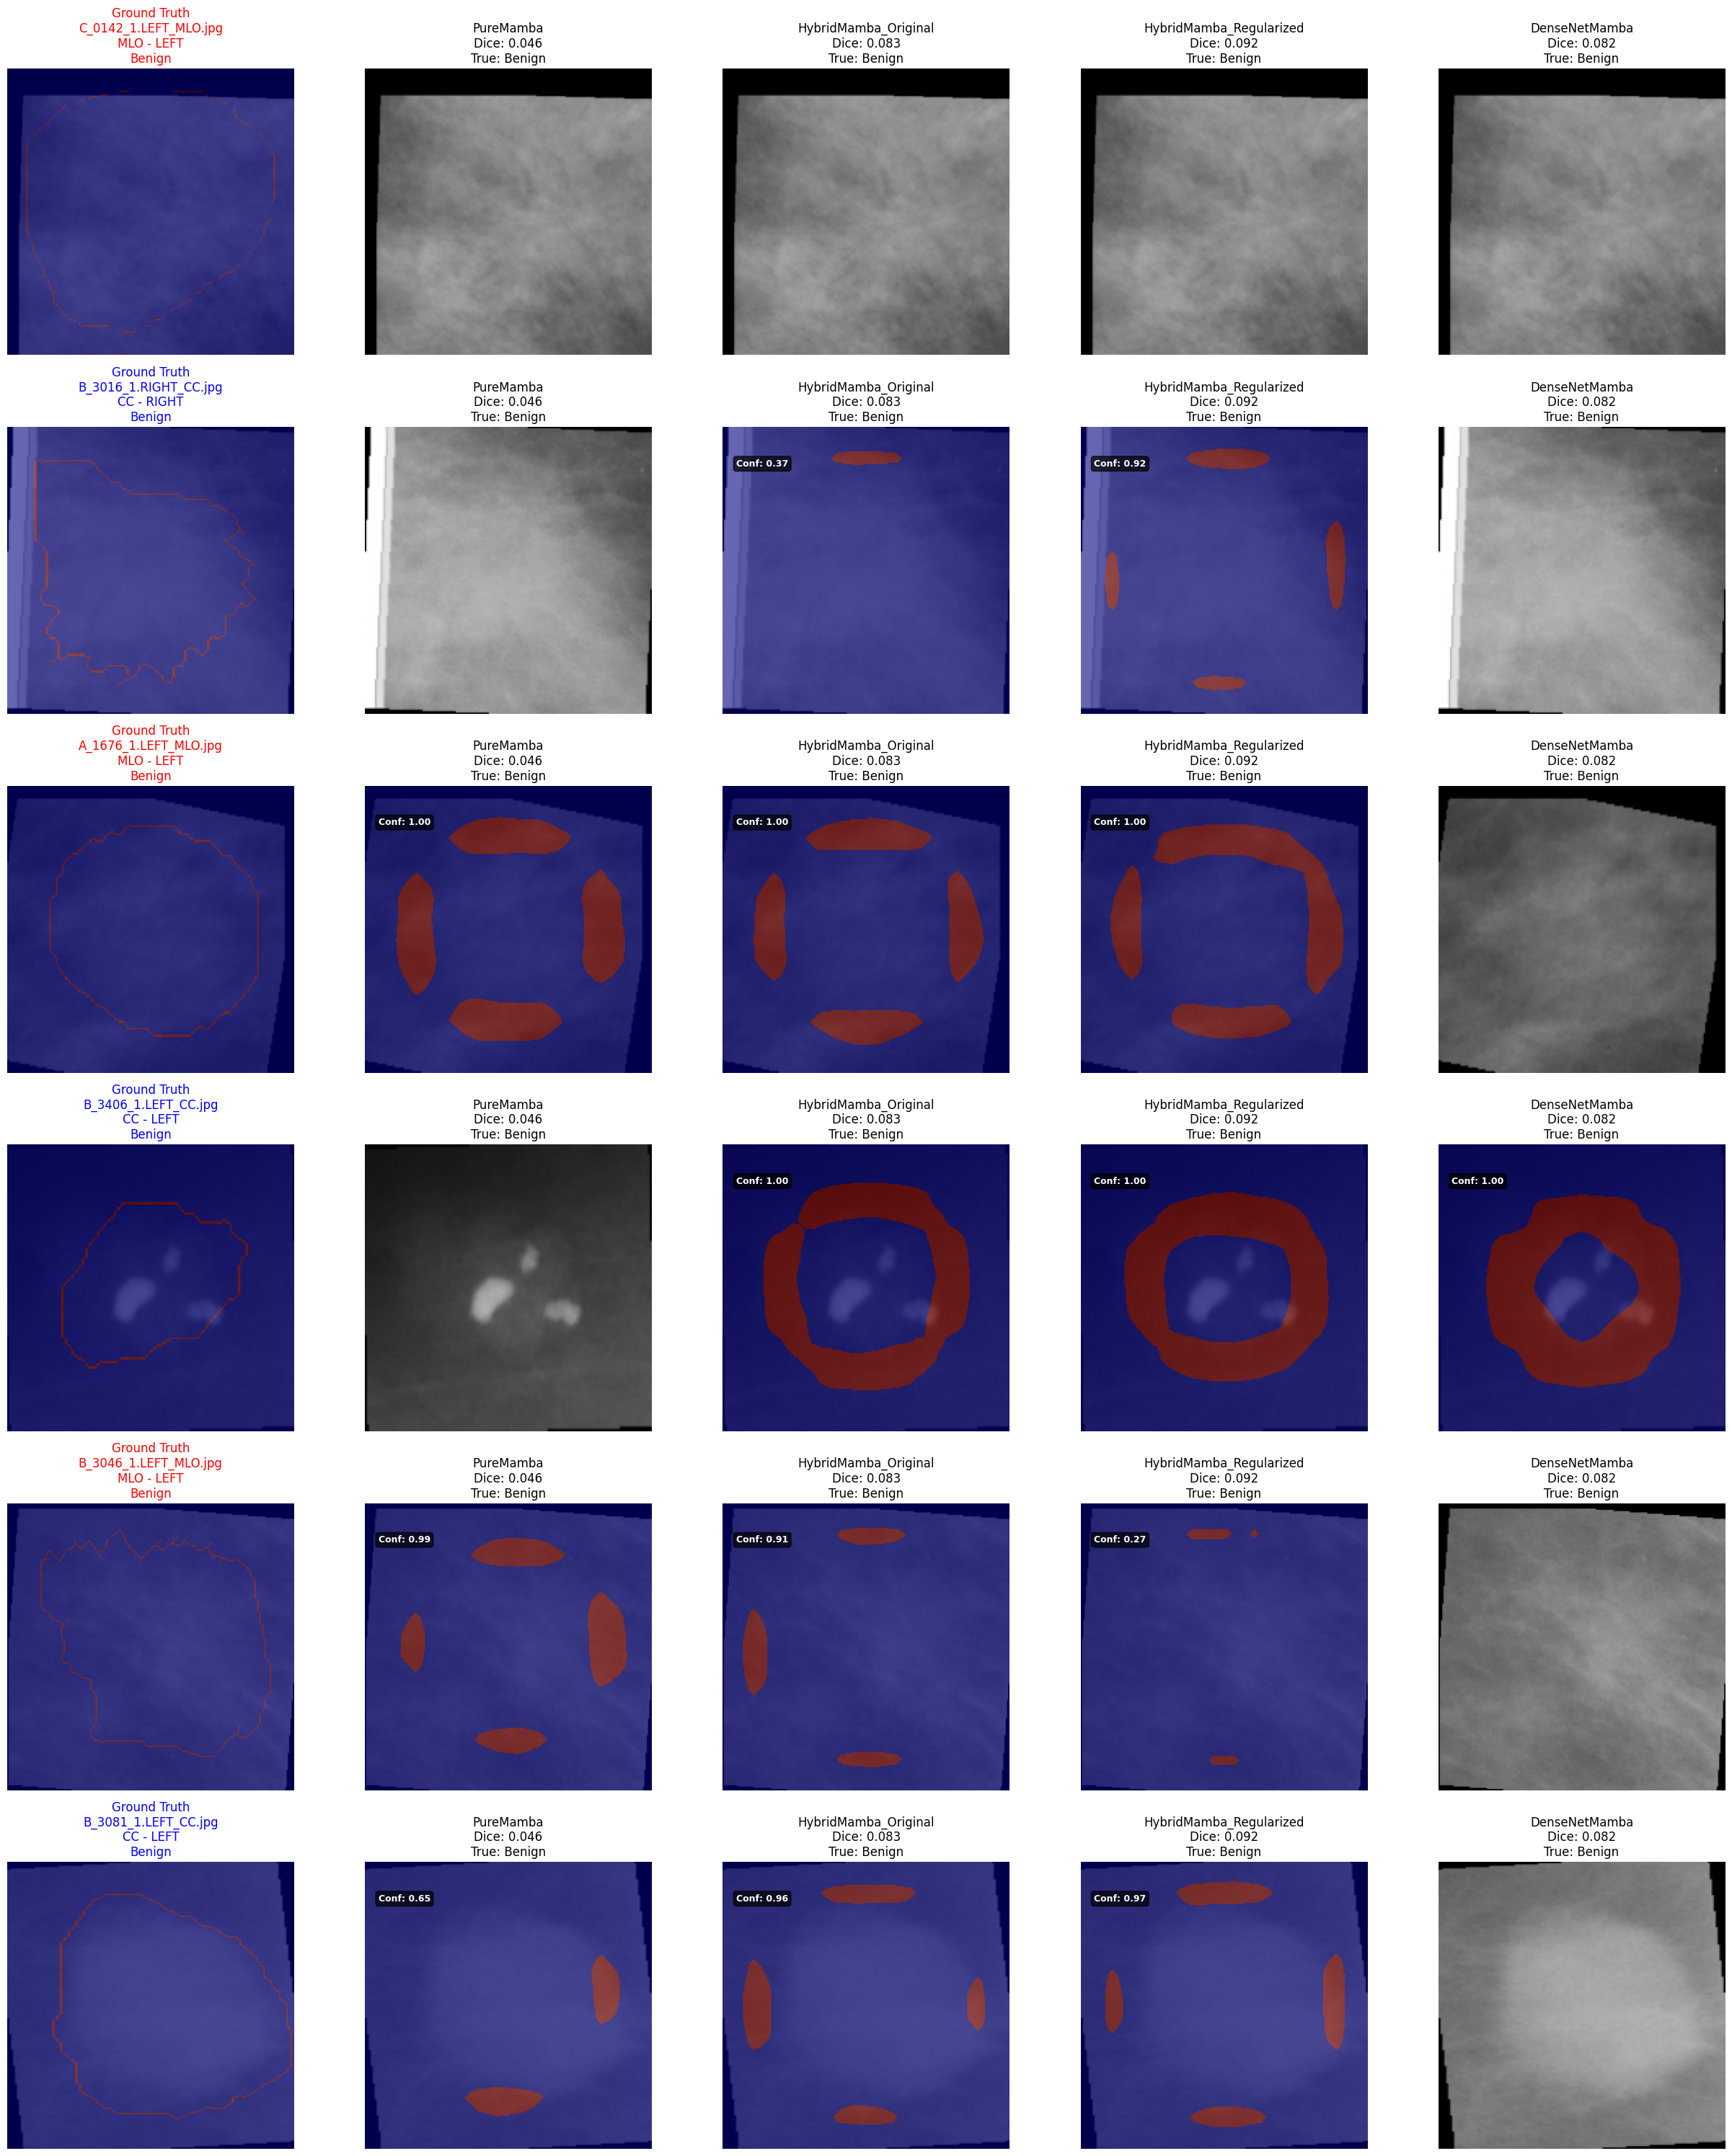

Saved comparison to /content/all_models_comparison.png
['MLO', 'CC', 'MLO', 'CC', 'MLO', 'CC']

MODEL COMPARISON SUMMARY
HybridMamba_Regularized: 0.0920
HybridMamba_Original: 0.0831
DenseNetMamba: 0.0816
PureMamba: 0.0464


In [75]:
# Run Everything

if __name__ == "__main__":
    print("Loading all saved segmentation models...")
    print("="*60)

    # Load all models
    models = load_all_saved_models()

    if not models:
        print("No saved models found! Run training first.")
    else:
        print(f"\nLoaded {len(models)} models")

        # Compare all models side by side
        compare_model_predictions(models, val_loader, num_samples=3)

        # Print summary
        print("\n" + "="*60)
        print("MODEL COMPARISON SUMMARY")
        print("="*60)
        for name, data in sorted(models.items(), key=lambda x: x[1]['best_dice'], reverse=True):
            print(f"{name}: {data['best_dice']:.4f}")

Explainability

In [ ]:
#Grad - Cam Explainability for All Models

def denormalize(tensor):
    tensor = tensor.clone().detach().cpu()
    mean = [0.485, 0.456, 0.406]
    std = [0.229, 0.224, 0.225]
    for t, m, s in zip(tensor, mean, std):
        t.mul_(s).add_(m)
    return t.clamp(0, 1)

class SimpleGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        original_mode = self.model.training
        self.model.train()
        self.model.zero_grad()

        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[:, class_idx].mean().backward()

        gradients = self.gradients
        activations = self.activations

        if gradients is None or activations is None:
            self.model.train(original_mode)
            return None, class_idx

        pooled_gradients = torch.mean(gradients, dim=[0, 2, 3])
        weighted_activations = activations * pooled_gradients[None, :, None, None]
        heatmap = torch.mean(weighted_activations, dim=1)
        heatmap = F.relu(heatmap)
        heatmap = heatmap.cpu().detach().numpy()

        if heatmap.ndim == 3:
            heatmap = heatmap[0]

        if heatmap.max() - heatmap.min() > 0:
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        self.model.train(original_mode)
        return heatmap, class_idx

def overlay_heatmap(image, heatmap, alpha=0.5):
    if heatmap.ndim > 2:
        heatmap = heatmap.squeeze()
    heatmap = cv2.resize(heatmap, (image.shape[1], image.shape[0]))
    heatmap = np.clip(heatmap, 0, 1)
    heatmap = (heatmap * 255).astype(np.uint8)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    return (alpha * heatmap + (1 - alpha) * image).astype(np.uint8)

def get_target_layer(model):
    if hasattr(model, 'classification_model'):
        if hasattr(model.classification_model, 'encoder'):
            for module in reversed(list(model.classification_model.encoder.modules())):
                if isinstance(module, torch.nn.Conv2d):
                    return module
        if hasattr(model.classification_model, 'projection'):
            if isinstance(model.classification_model.projection, torch.nn.Conv2d):
                return model.classification_model.projection
    if hasattr(model, 'classification_model') and hasattr(model.classification_model, 'backbone'):
        for module in reversed(list(model.classification_model.backbone.modules())):
            if isinstance(module, torch.nn.Conv2d):
                return module
    for module in reversed(list(model.modules())):
        if isinstance(module, torch.nn.Conv2d):
            return module
    return None

def get_random_balanced_images(num_images=5):
   
    benign_paths = []
    malignant_paths = []

    for root, dirs, files in os.walk('/content/MINI-DDSM'):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                if 'benign' in root.lower():
                    benign_paths.append(os.path.join(root, file))
                elif 'malignant' in root.lower() or 'cancer' in root.lower():
                    malignant_paths.append(os.path.join(root, file))

    print(f"Found: {len(benign_paths)} Benign, {len(malignant_paths)} Malignant")

    random.seed(42)
    num_each = num_images // 2
    selected = []
    if len(benign_paths) >= num_each:
        selected.extend(random.sample(benign_paths, num_each))
    else:
        selected.extend(benign_paths)
    if len(malignant_paths) >= num_each:
        selected.extend(random.sample(malignant_paths, num_each))
    else:
        selected.extend(malignant_paths)

    return selected

def explain_image(model, image_path, device='cuda'):
    
    original_image = Image.open(image_path).convert('RGB')
    input_tensor = val_transform(original_image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(input_tensor)
        probs = torch.softmax(output, dim=1)
        predicted_class = output.argmax(dim=1).item()
        confidence = probs[0][predicted_class].item()

    target_layer = get_target_layer(model)
    if target_layer is None:
        return None

    gradcam = SimpleGradCAM(model, target_layer)
    input_batch = torch.cat([input_tensor, input_tensor], dim=0)
    heatmap, _ = gradcam.generate(input_batch, predicted_class)

    if heatmap is None:
        return None

    original_np = np.array(original_image.resize((224, 224)))
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    overlay = overlay_heatmap(original_np, heatmap_resized)

    true_class = 'Benign' if 'benign' in image_path.lower() else 'Malignant'
    pred_class = 'Malignant' if predicted_class == 1 else 'Benign'
    is_correct = true_class == pred_class

    return {
        'original': original_np,
        'heatmap': heatmap_resized,
        'overlay': overlay,
        'predicted_class': predicted_class,
        'confidence': confidence,
        'predicted_name': pred_class,
        'true_name': true_class,
        'correct': is_correct
    }

Found: 4175 Benign, 4290 Malignant

Selected 6 images:
  1. Benign: B_3359_1.LEFT_CC_Mask.jpg
  2. Benign: A_1275_1.LEFT_CC.jpg
  3. Benign: C_0414_1.RIGHT_MLO.jpg
  4. Malignant: A_1619_1.RIGHT_CC.jpg
  5. Malignant: B_3054_1.LEFT_CC.jpg
  6. Malignant: C_0014_1.RIGHT_CC.jpg

PureMamba


/tmp/ipykernel_51847/467786069.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=device)


Validation Accuracy: 50.21%
  ✗ Benign → Malignant (55.7%)
  ✗ Benign → Malignant (53.2%)
  ✗ Benign → Malignant (59.2%)
  ✓ Malignant → Malignant (56.3%)
  ✓ Malignant → Malignant (54.9%)
  ✓ Malignant → Malignant (53.4%)


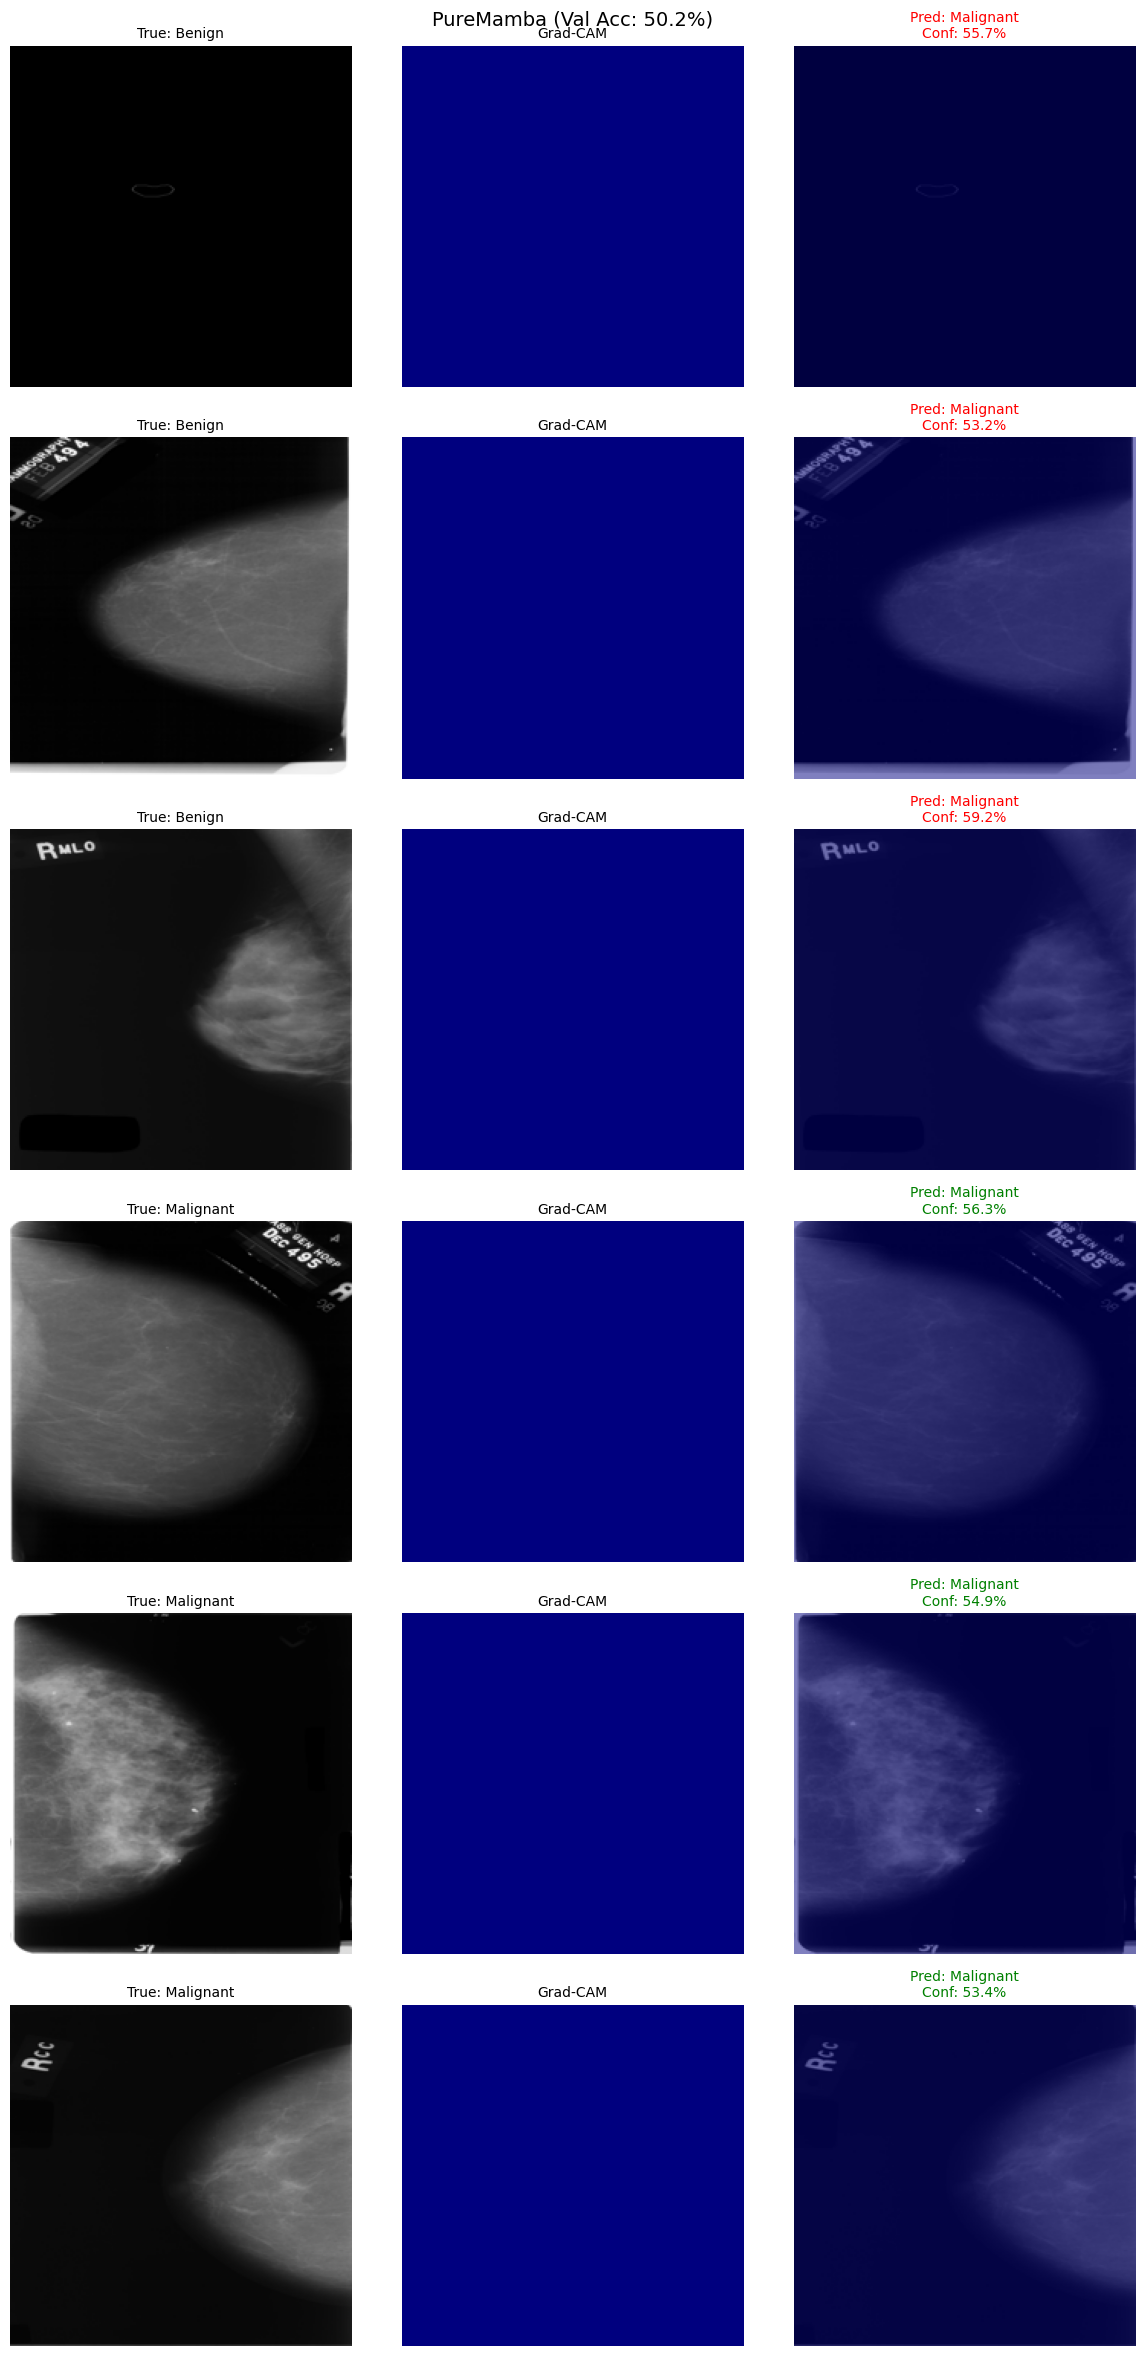

Saved: PureMamba_explanations.png

HybridMamba_Original
Validation Accuracy: 71.23%
  ✓ Benign → Benign (99.9%)
  ✓ Benign → Benign (99.9%)
  ✓ Benign → Benign (99.8%)
  ✓ Malignant → Malignant (100.0%)
  ✓ Malignant → Malignant (100.0%)
  ✓ Malignant → Malignant (100.0%)


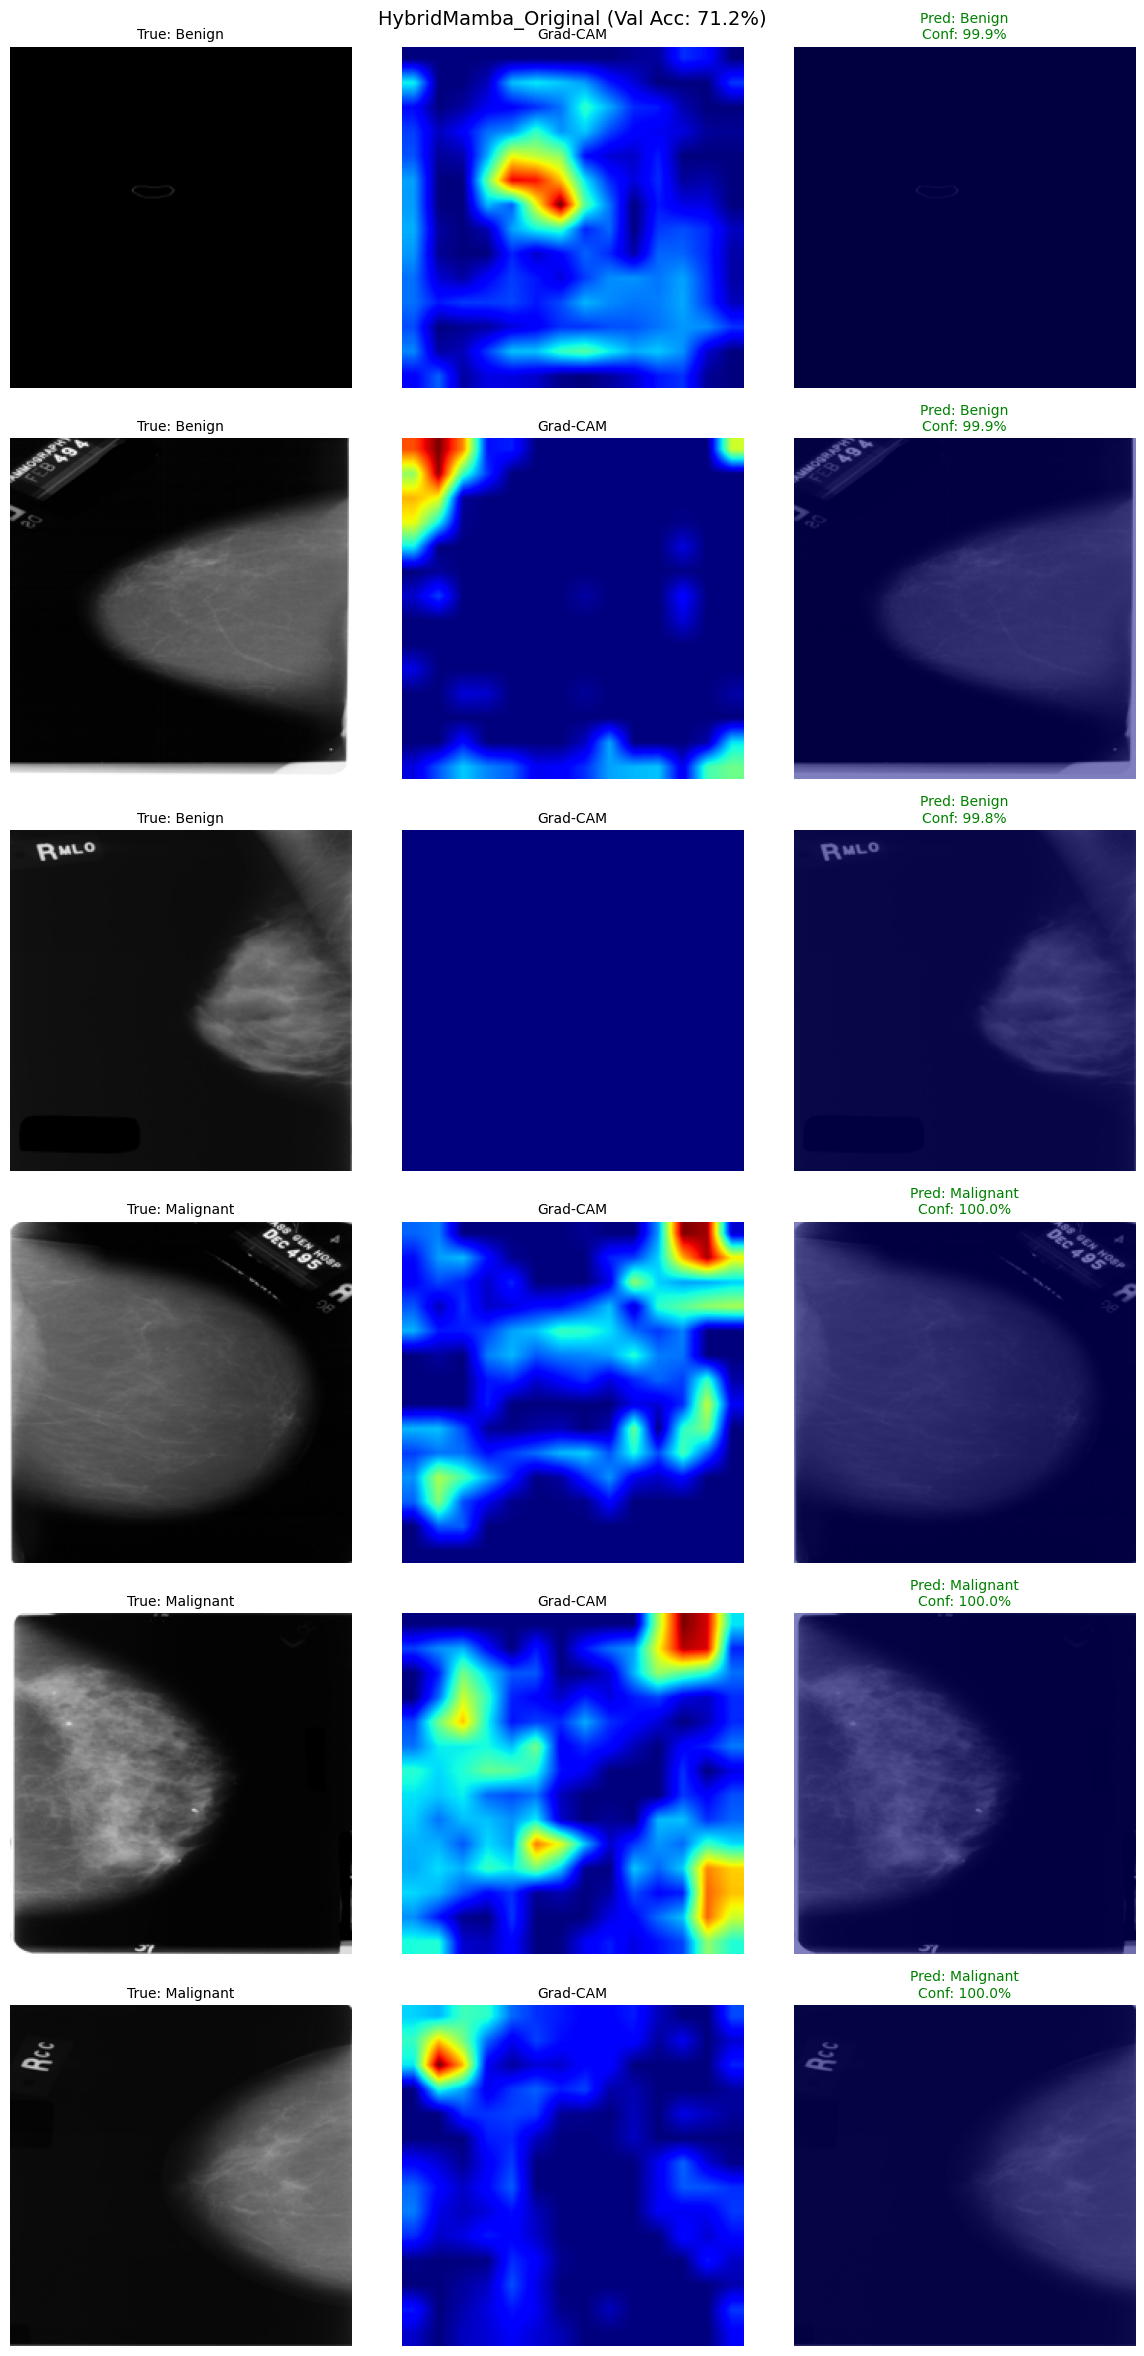

Saved: HybridMamba_Original_explanations.png

HybridMamba_Regularized
Validation Accuracy: 71.47%

DenseNetMamba
Validation Accuracy: 70.29%
  ✓ Benign → Benign (66.4%)
  ✓ Benign → Benign (97.6%)
  ✓ Benign → Benign (98.7%)
  ✓ Malignant → Malignant (99.4%)
  ✓ Malignant → Malignant (99.9%)
  ✓ Malignant → Malignant (100.0%)


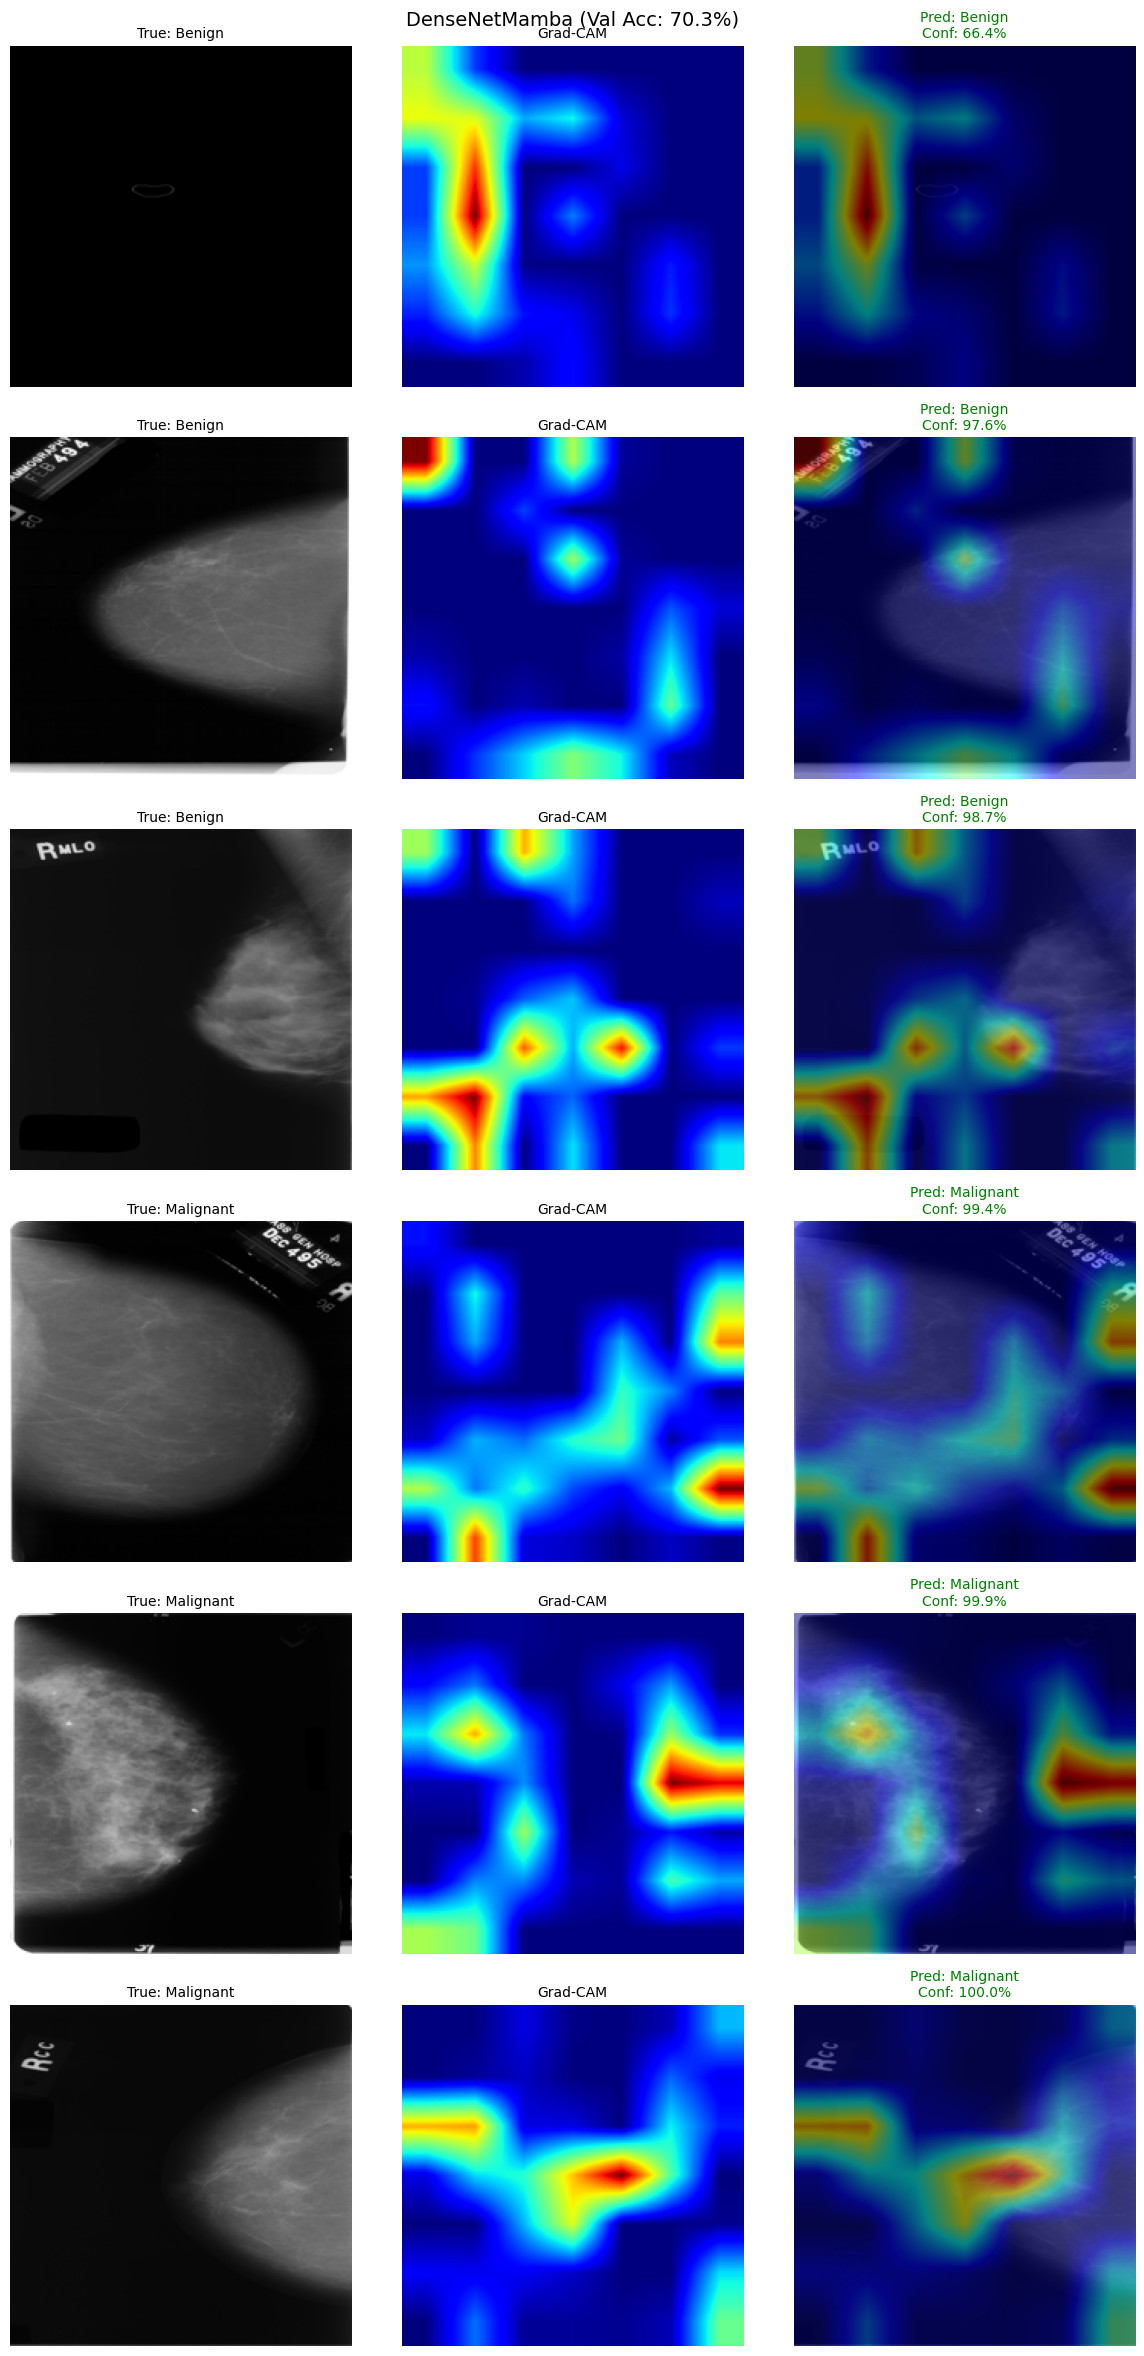

Saved: DenseNetMamba_explanations.png


In [77]:
# Get balanced random images
image_paths = get_random_balanced_images(6)  # 3 benign, 3 malignant
print(f"\nSelected {len(image_paths)} images:")
for i, path in enumerate(image_paths):
    label = 'Benign' if 'benign' in path.lower() else 'Malignant'
    print(f"  {i+1}. {label}: {os.path.basename(path)}")

# Generate explanations for all models
for config in models_config:
    print(f"\n{'='*60}")
    print(f"{config['name']}")
    print(f"{'='*60}")

    checkpoint_path = f'/content/model_checkpoints/{config["name"]}_best.pth'
    if not os.path.exists(checkpoint_path):
        print(f"Checkpoint not found")
        continue

    model = config['class'](**config['params']).to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    # Get model accuracy from checkpoint
    metrics = checkpoint.get('metrics', {})
    val_acc = metrics.get('val_acc', 'N/A')
    print(f"Validation Accuracy: {val_acc if val_acc == 'N/A' else f'{val_acc:.2f}%'}")

    # Generate explanations
    results = []
    for img_path in image_paths:
        result = explain_image(model, img_path, device)
        if result:
            results.append(result)
            status = "✓" if result['correct'] else "✗"
            print(f"  {status} {result['true_name']} → {result['predicted_name']} ({result['confidence']:.1%})")

    # Create composite figure
    if results:
        fig, axes = plt.subplots(len(results), 3, figsize=(12, 4*len(results)))
        if len(results) == 1:
            axes = axes.reshape(1, -1)

        fig.suptitle(f'{config["name"]} (Val Acc: {val_acc if val_acc == "N/A" else f"{val_acc:.1f}%"})', fontsize=14)

        for i, result in enumerate(results):
            axes[i, 0].imshow(result['original'])
            axes[i, 0].set_title(f'True: {result["true_name"]}', fontsize=10)
            axes[i, 0].axis('off')

            axes[i, 1].imshow(result['heatmap'], cmap='jet')
            axes[i, 1].set_title('Grad-CAM', fontsize=10)
            axes[i, 1].axis('off')

            axes[i, 2].imshow(result['overlay'])
            color = 'green' if result['correct'] else 'red'
            title = f"Pred: {result['predicted_name']}\nConf: {result['confidence']:.1%}"
            axes[i, 2].set_title(title, color=color, fontsize=10)
            axes[i, 2].axis('off')

        plt.tight_layout()
        plt.savefig(f'{config["name"]}_explanations.png', dpi=300, bbox_inches='tight')
        plt.show()
        print(f"Saved: {config['name']}_explanations.png")